# Temporal Conformal Calibration and Predictive Intervals

In this notebook, the uncertainty layer is calibrated over the already frozen development OOF predictions. Point Champion E0 is preserved, no estimator is refitted, and the final holdout is not reopened.

Because the initial execution is performed in smoke mode, the infrastructure is validated without producing a definitive ranking.


In [1]:
import sys
from pathlib import Path
import warnings

PROJECT_ROOT = next(
    filter(
        lambda candidate: (
            (candidate / 'src').is_dir()
            and (candidate / 'notebooks').is_dir()
        ),
        (Path.cwd(), *Path.cwd().parents),
    )
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from matplotlib import pyplot as plt

from src import conformal_uncertainty_reports as reports
from src.conformal_uncertainty import (
    ConformalUncertaintyConfig,
    conformal_method_specs,
    load_conformal_calibration_results,
)
from src.i18n import make_lang
from src.plotting import set_graph_parameters

warnings.filterwarnings('ignore', category=FutureWarning)
set_graph_parameters()
plt.rcParams['axes.grid'] = False
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

lang = make_lang('en')


## 1. Objective and Experimental Boundaries

It was investigated whether E0 historical errors could be converted into empirically calibrated intervals without modifying its central prediction. The comparison was restricted to the uncertainty layer, and no confirmatory conclusion was authorized at this stage.

The CQR method of Romano, Patterson, and Candès (2019) was retained as a future hypothesis because its inclusion would require new quantile models and would exceed the post-modeling scope of this notebook.


In [2]:
reports.environment_report(lang=lang)


,Item,Value
0,Conda environment,Bike-Sharing
1,Interpreter (sys.executable),Bike-Sharing/python.exe
2,Python version,3.10.20
3,Environment fingerprint,8f80d9216d47a792
4,Differences from environment.yml,none
5,Dependencies declared with the model,"mlflow==2.10.0, cloudpickle==3.1.2, numpy==1.2..."
6,scikit-learn,1.3.2
7,pandas,2.2.3
8,numpy,1.26.4
9,mlflow,2.10.0


## 2. Environment and Frozen Artifacts

The `Bike-Sharing` environment is required prior to execution. The manifest and OOF predictions produced by Notebook 06 are treated as frozen inputs, and their fingerprints and hashes are audited before calibration.

Access to the holdout remains blocked. Only the E0 points and the experimental scale of E4 are aligned by fold, meteorological year, and timestamp.


In [3]:
config = ConformalUncertaintyConfig(run_mode='full')
display(reports.protocol_report(config, lang=lang))


,Item,Value
0,Execution mode,full
1,Nature of the conclusion,experimental candidate for the uncertainty layer
2,Use of the final holdout,not used
3,Prediction source,frozen OOF predictions from Notebook 06
4,Interval center,E0
5,Warm-up per fold,168 hours
6,State reset,at each fold and regime change
7,Evaluated coverage levels,"80%, 90%, 95%"
8,2020 policy,"separate report, outside the ranking"
9,Temporal bootstrap,500 replications; 168-hour blocks


## 3. Prequential Contract and Leakage Prevention

Within each fold, the first 168 hours are reserved for warming up the uncertainty layer. Point predictions remain available during this period, but no conformal interval is constructed or scored.

At hour `t`, only scores with earlier timestamps are used. After `y_t` is observed, the state is updated exclusively for `t+1`. The state is reset at each fold and regime change, preventing 2020 from feeding subsequent years.


## 4. Calibrator Specification

Methods U0–U5 are preregistered. A symmetric expanding baseline, an asymmetric rolling version, recency weighting, normalization by the E4 scale, observation-level ACI, and hierarchical calibration by regime are compared.

Because exchangeability is weakened by temporal dependence, the results are interpreted as empirical diagnostics. Recency weighting is motivated by the extension beyond exchangeability discussed by Barber et al. (2023), while the adaptive update follows Gibbs and Candès (2021).


In [4]:
reports.method_spec_report(conformal_method_specs(config), lang=lang)


,Candidate,Method,Specification,Calibration window,Nonconformity,Adaptive alpha,Uses E4 scale,Status,Notes
0,U0,U0,Conformal expansível simétrico,expanding_within_fold,absolute_residual,False,False,planned,
1,U1,U1,Conformal rolling assimétrico,rolling_2160h,signed_residual,False,False,planned,
2,U2_h168,U2,"Conformal ponderado por recência, meia-vida 168h",rolling_2160h,recency_weighted_absolute_residual,False,False,planned,half_life_hours=168
3,U2_h720,U2,"Conformal ponderado por recência, meia-vida 720h",rolling_2160h,recency_weighted_absolute_residual,False,False,planned,half_life_hours=720
4,U2_h2160,U2,"Conformal ponderado por recência, meia-vida 2160h",rolling_2160h,recency_weighted_absolute_residual,False,False,planned,half_life_hours=2160
5,U3,U3,Conformal normalizado pela escala E4,rolling_2160h,absolute_residual_over_e4_scale,False,True,planned,
6,U4a_g0p001,U4a,"ACI sobre o erro absoluto, gamma=0.001",rolling_2160h,adaptive_absolute_residual,True,False,planned,gamma=0.001
7,U4b_g0p001,U4b,"ACI normalizado pela escala E4, gamma=0.001",rolling_2160h,adaptive_normalized_residual,True,True,planned,gamma=0.001
8,U4a_g0p005,U4a,"ACI sobre o erro absoluto, gamma=0.005",rolling_2160h,adaptive_absolute_residual,True,False,planned,gamma=0.005
9,U4b_g0p005,U4b,"ACI normalizado pela escala E4, gamma=0.005",rolling_2160h,adaptive_normalized_residual,True,True,planned,gamma=0.005


## 5. Execution and Provenance

A single call applies the calibrators to the frozen predictions. No estimator training or prediction calls are made, and only the required columns are read from the source artifacts.


In [5]:
results = load_conformal_calibration_results(config)
display(reports.source_provenance_report(results, lang=lang))
reports.input_audit_report(results, lang=lang)

,Item,Value
0,Source code version,uncertainty_experiments_v1
1,Source artifact mode,full
2,Dataset fingerprint,24f188a95febd94d
3,Regime fingerprint,1043b392ad5e2806
4,Source temporal validation,ForwardMeteorologicalYearSplit_v3_normal_opera...


,Artifact,Path,Bytes,SHA-256
0,source_manifest,dataset/normal_operations/uncertainty_experime...,8853,be919c91fa8a4cc77f547289f1188889c2936dcc2ef32c...
1,source_predictions,dataset/normal_operations/uncertainty_experime...,89568037,8c074fecdff256173b3010443c7f3b217522f51a7cf74b...


## 6. Warm-up and Operational Availability

Availability of intervals is audited by fold and candidate. The warm-up period is excluded from metrics, so that the absence of history is not confused with coverage equal to zero.


In [6]:
reports.warmup_report(results, lang=lang)


,Candidate,Nominal coverage,Fold,Meteorological year,Fold role,Total observations,Warm-up observations,Scored observations,Maximum history
0,U0,0.80,1,2019,selection,8715,168,8547,8714
1,U0,0.90,1,2019,selection,8715,168,8547,8714
2,U0,0.95,1,2019,selection,8715,168,8547,8714
3,U0,0.80,2,2020,stress,8759,168,8591,8758
4,U0,0.90,2,2020,stress,8759,168,8591,8758
...,...,...,...,...,...,...,...,...,...
190,U5,0.90,4,2022,selection,8759,168,8591,2160
191,U5,0.95,4,2022,selection,8759,168,8591,2160
192,U5,0.80,5,2023,selection,8760,168,8592,2160
193,U5,0.90,5,2023,selection,8760,168,8592,2160


## 7. Expanding Conformal Baseline — U0

In U0, the corrected quantile is calculated from an expanding history of prior absolute errors within each fold. Consequently, even 2019 becomes calibratable after its first 168 hours without using future residuals.


## 8. Temporal Asymmetry — U1

In U1, the lower and upper quantiles of the signed residuals are estimated separately in a rolling window of 2,160 hours. The lower bound of demand at zero is preserved, and each tail's violations are reported separately.


## 9. Recency Weighting — U2

In U2, exponential weights are applied to the preceding history, with half-lives of 168, 720, and 2,160 hours. Every variant is displayed so that no configuration is silently selected from the same results.


In [7]:
reports.sensitivity_report(results, 'U2', lang=lang)


,Variant,Observed coverage,Coverage error,Average width,Winkler score
20,U2_h168,0.894270,-0.005730,3239.474294,5021.881360
22,U2_h720,0.878209,-0.021791,3099.351328,5240.044560
23,U2_h2160,0.867621,-0.032379,3020.891215,5369.323632


## 10. Probabilistic Scale of E4 — U3

In U3, the E0 point prediction is retained, and only the interval width is normalized by E4 `predicted_scale`. Spearman correlation and error by decile are examined before this scale is interpreted as local risk information.

Invalid scale values are treated by explicit fallback to absolute error. No silent filling is applied.


,Scope,Scale decile,Observations,Mean predicted scale,E0 mean absolute error,Spearman correlation,Monotonic growth rate
0,overall,1,3500,0.250364,1008.144269,-0.135017,0.222222
1,overall,2,3499,0.250698,877.939694,-0.135017,0.222222
2,overall,3,3499,0.251044,771.640972,-0.135017,0.222222
3,overall,4,3500,0.251539,699.310803,-0.135017,0.222222
4,overall,5,3499,0.252541,680.906166,-0.135017,0.222222
5,overall,6,3499,0.259857,889.466403,-0.135017,0.222222
6,overall,7,3500,0.321573,1342.967360,-0.135017,0.222222
7,overall,8,3499,0.878711,907.648288,-0.135017,0.222222
8,overall,9,3499,1.006217,507.747493,-0.135017,0.222222
9,overall,10,3500,1.051949,504.392748,-0.135017,0.222222


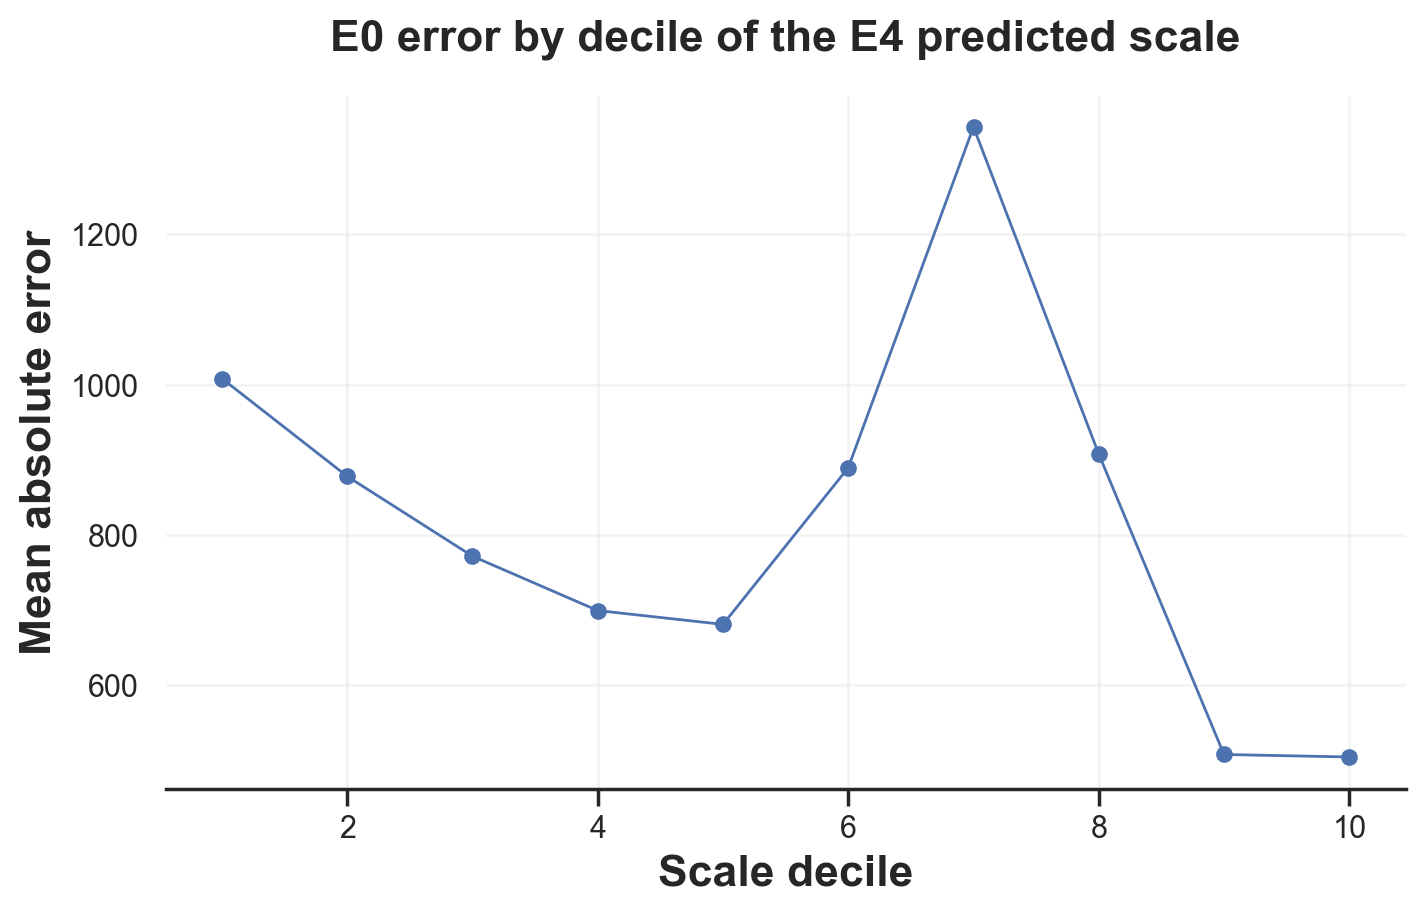

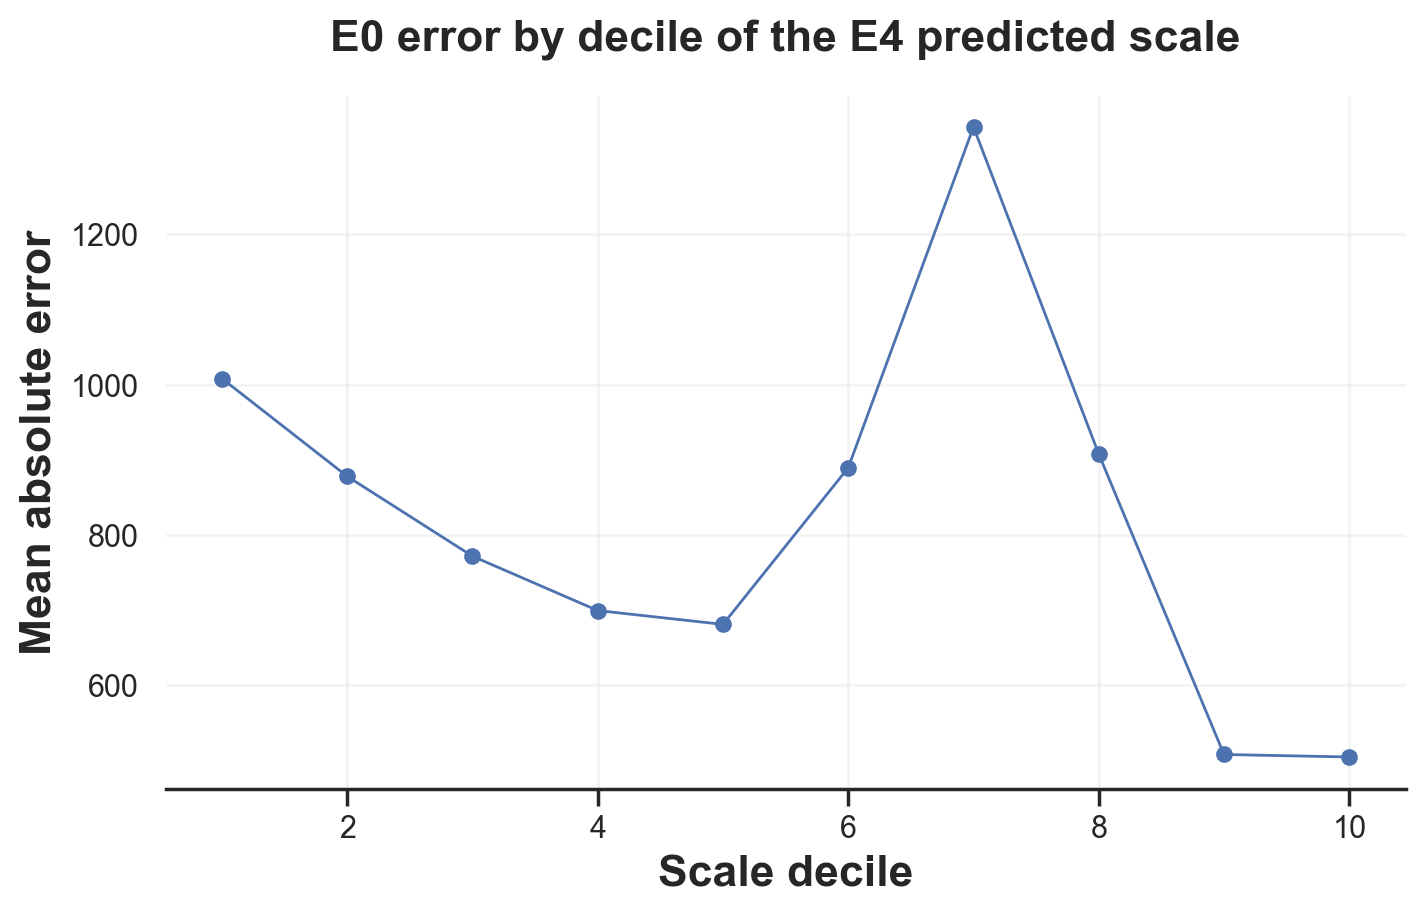

In [8]:
display(reports.scale_diagnostics_report(results, lang=lang))
reports.plot_scale_diagnostics(results, lang=lang)

## 11. Adaptive Conformal Inference — U4

In U4, `alpha_t` is updated after each observed point. When a violation occurs, the alpha is reduced and the subsequent interval is widened; when there is coverage, the adjustment occurs gradually in the opposite direction.

The error-based and normalized error versions by E4 are compared, under steps of 0.001, 0.005, and 0.01, according to the logic of Gibbs and Candès (2021).


,Variant,Observed coverage,Coverage error,Average width,Winkler score
16,U4a_g0p01,0.901659,0.001659,3334.975219,4895.725881
18,U4a_g0p005,0.902775,0.002775,3363.234155,4956.182449
21,U4a_g0p001,0.902059,0.002059,3445.978002,5088.844671


,Variant,Observed coverage,Coverage error,Average width,Winkler score
14,U4b_g0p01,0.901460,0.001460,3351.031061,4836.901802
17,U4b_g0p005,0.902725,0.002725,3383.733688,4901.799832
19,U4b_g0p001,0.902758,0.002758,3500.802718,5021.338938


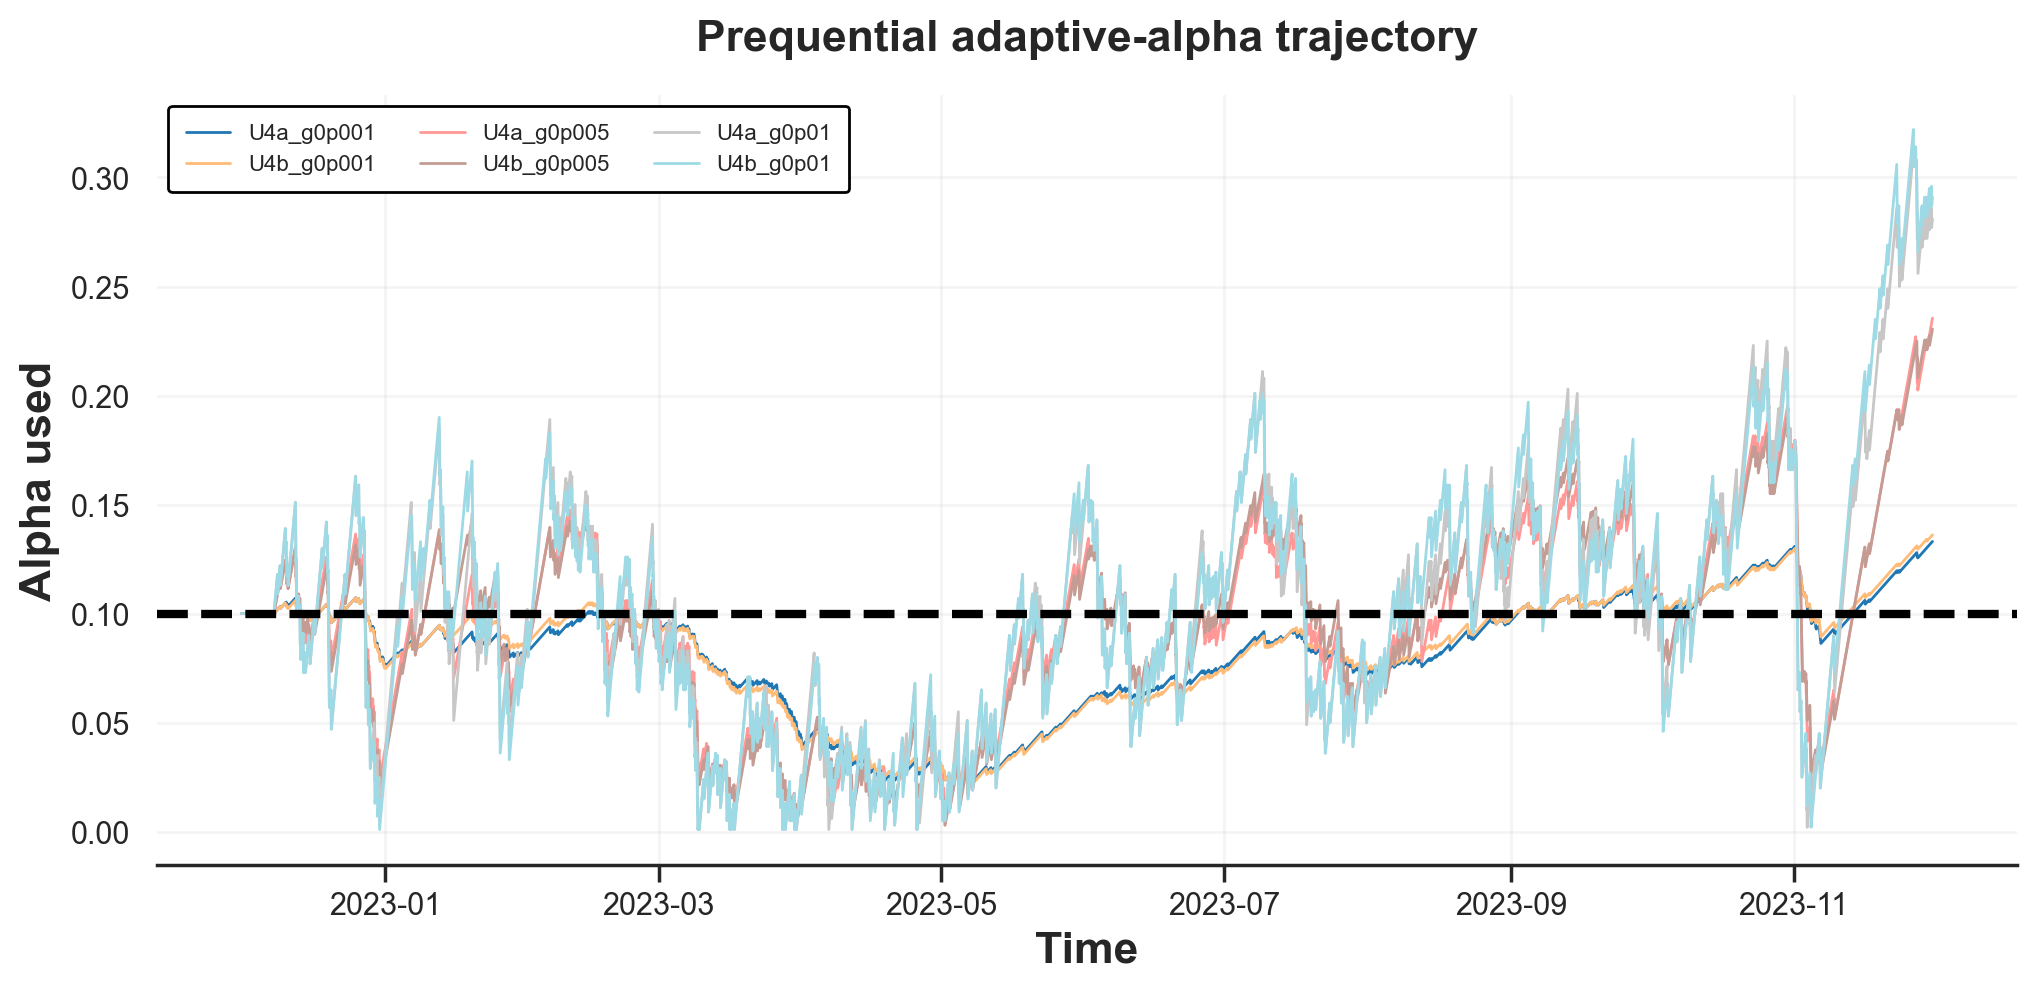

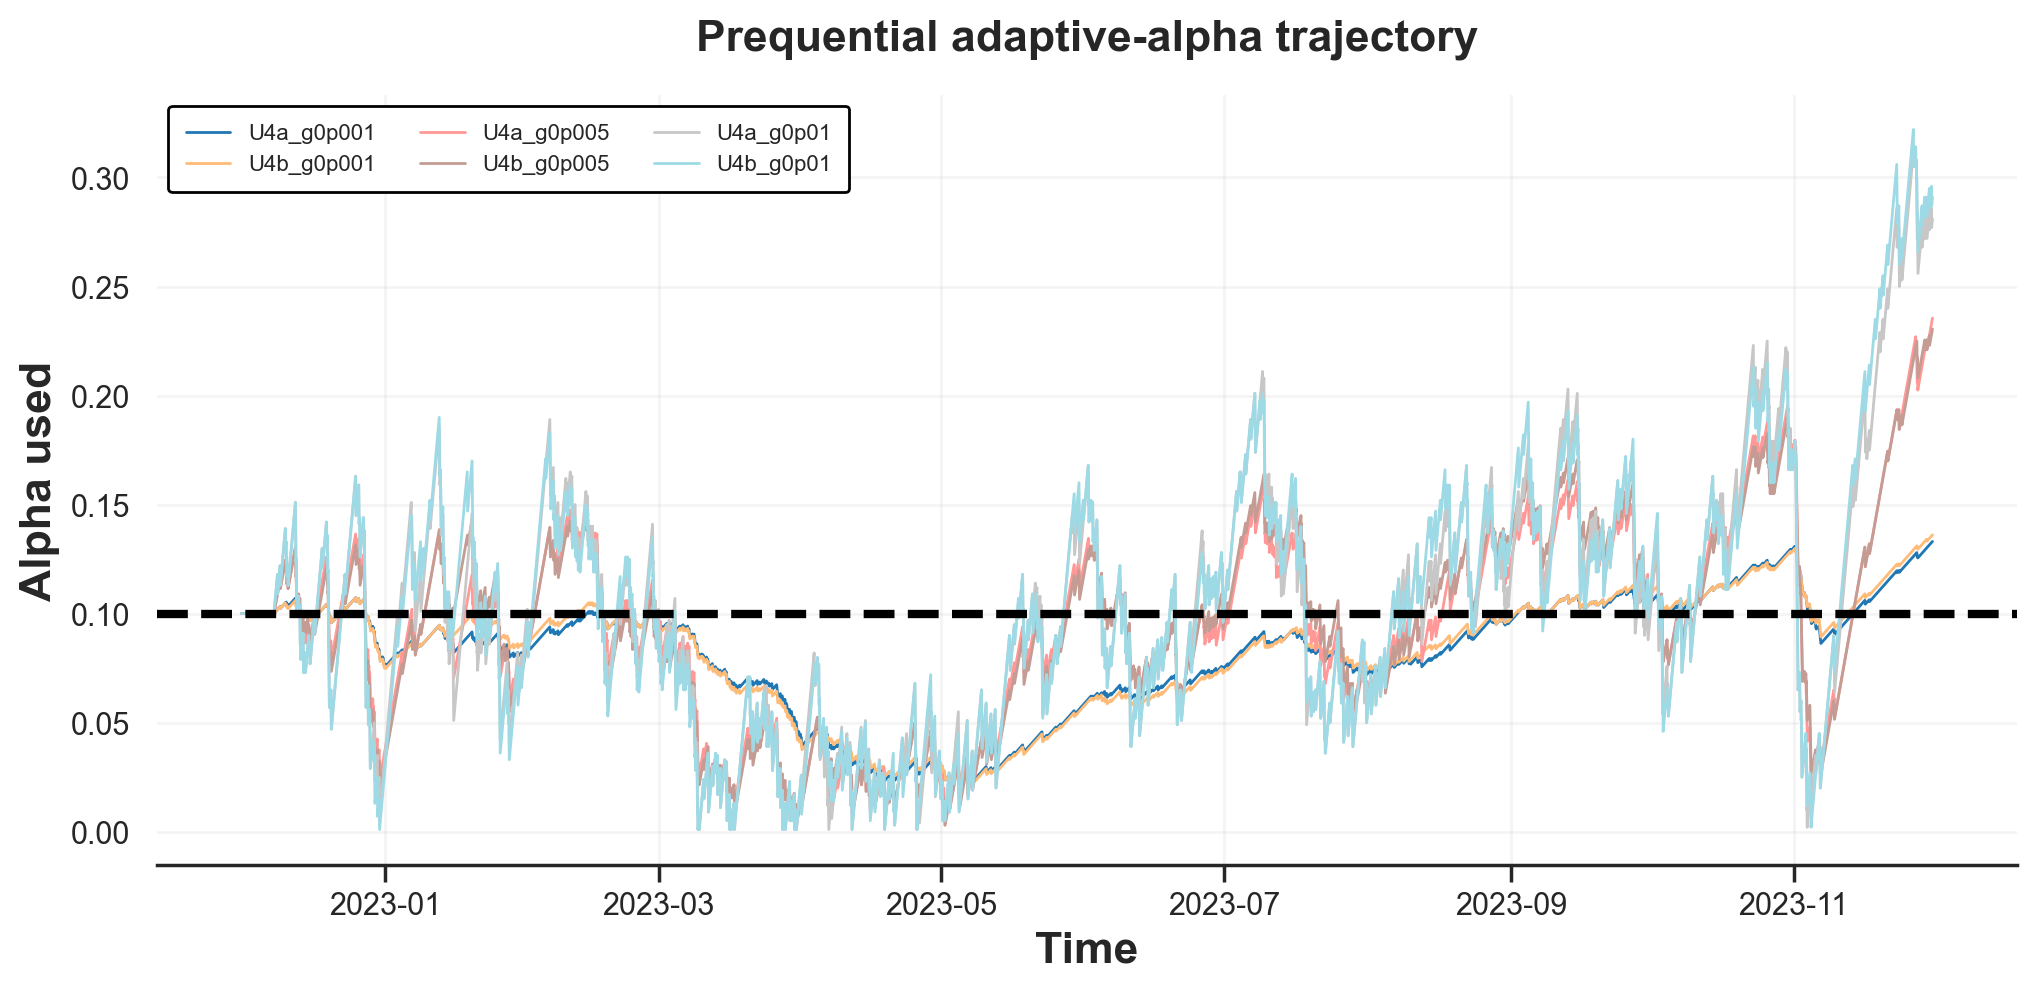

In [9]:
display(reports.sensitivity_report(results, 'U4a', lang=lang))
display(reports.sensitivity_report(results, 'U4b', lang=lang))
reports.plot_aci_alpha_trajectory(results, lang=lang)


## 12. Hierarchical Calibration by Regime — U5

In U5, signed residuals are calibrated through the hierarchy `Rush_Period × Rainfall Cat × Seasons`, followed by progressively broader levels. Fallback use is recorded whenever the most specific group does not yet have sufficient history.

Only variables known at the time of prediction are used in the calibration. Predicted demand ranges are used only in the audit of the results.


,Candidate,Segment type,Segment,Observations,Observed coverage,Coverage error,Average width,Winkler score,Fallback rate,Undercoverage alert
0,U0,Rush_Period,Evening Rush,3884,0.529609,-0.370391,2535.372819,13656.124286,0.000000,True
1,U0,Rush_Period,Morning Rush,2916,0.608368,-0.291632,2522.549060,11718.478684,0.000000,True
3,U1,Rush_Period,Evening Rush,3884,0.674047,-0.225953,2640.854314,8682.689354,0.000000,True
4,U1,Rush_Period,Morning Rush,2916,0.737654,-0.162346,2633.431640,7885.576773,0.000000,True
6,U2_h168,Rush_Period,Evening Rush,3884,0.666581,-0.233419,3407.582560,9150.000902,0.000000,True
7,U2_h168,Rush_Period,Morning Rush,2916,0.748971,-0.151029,3349.393991,8201.840190,0.000000,True
9,U2_h2160,Rush_Period,Evening Rush,3884,0.622812,-0.277188,3179.490713,10647.151375,0.000000,True
10,U2_h2160,Rush_Period,Morning Rush,2916,0.712620,-0.187380,3143.909247,9310.568018,0.000000,True
12,U2_h720,Rush_Period,Evening Rush,3884,0.641864,-0.258136,3262.840943,10111.403167,0.000000,True
13,U2_h720,Rush_Period,Morning Rush,2916,0.727366,-0.172634,3221.962700,8900.479094,0.000000,True


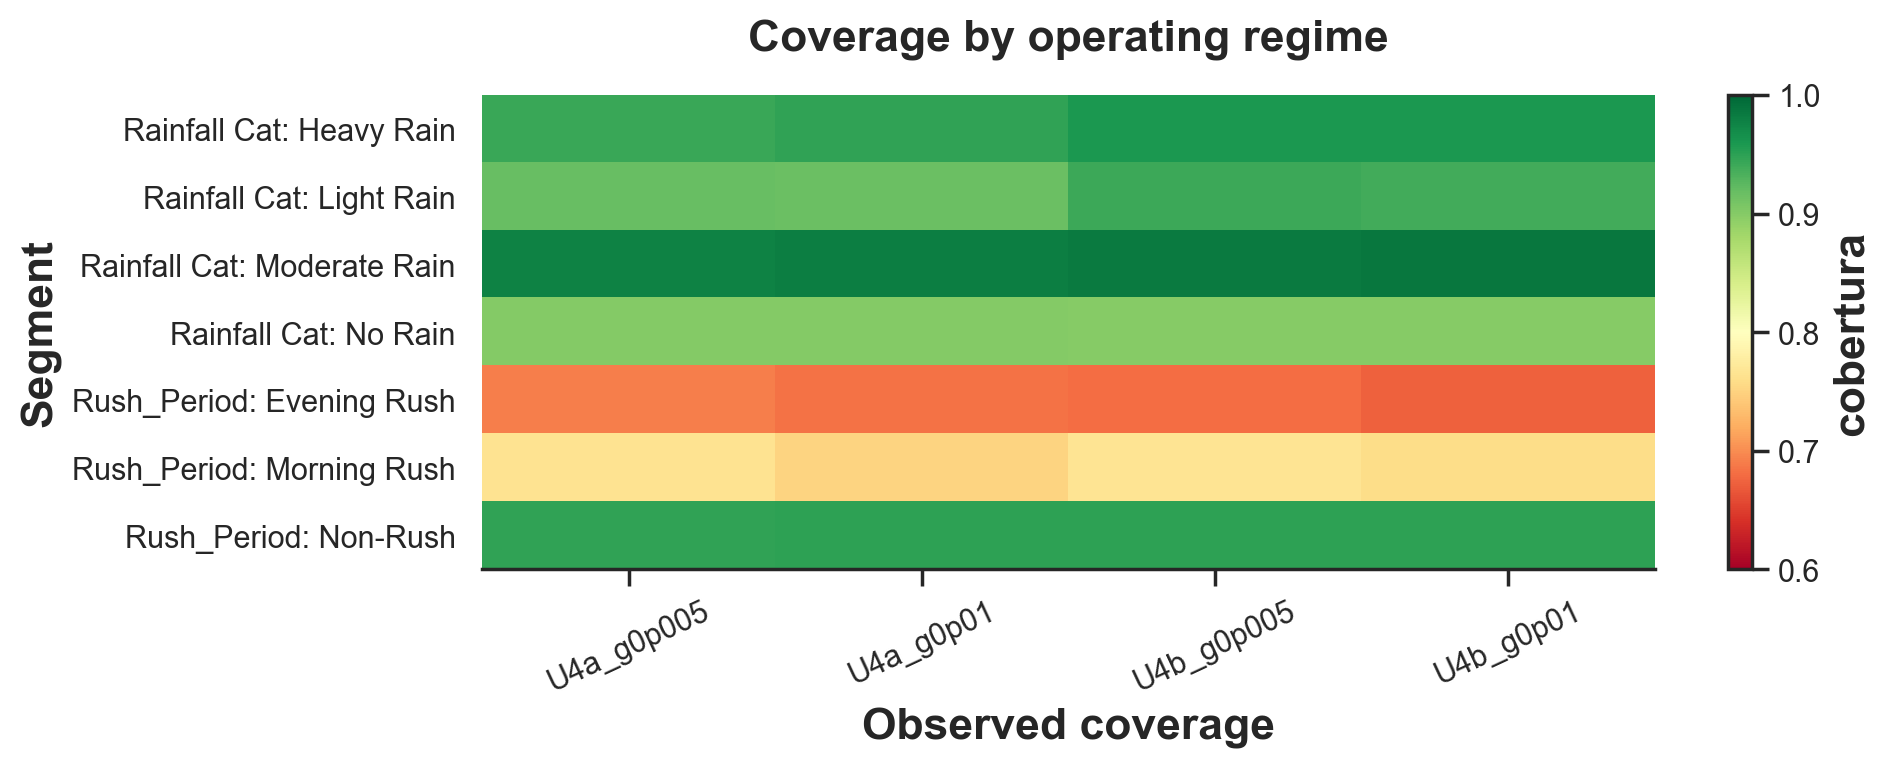

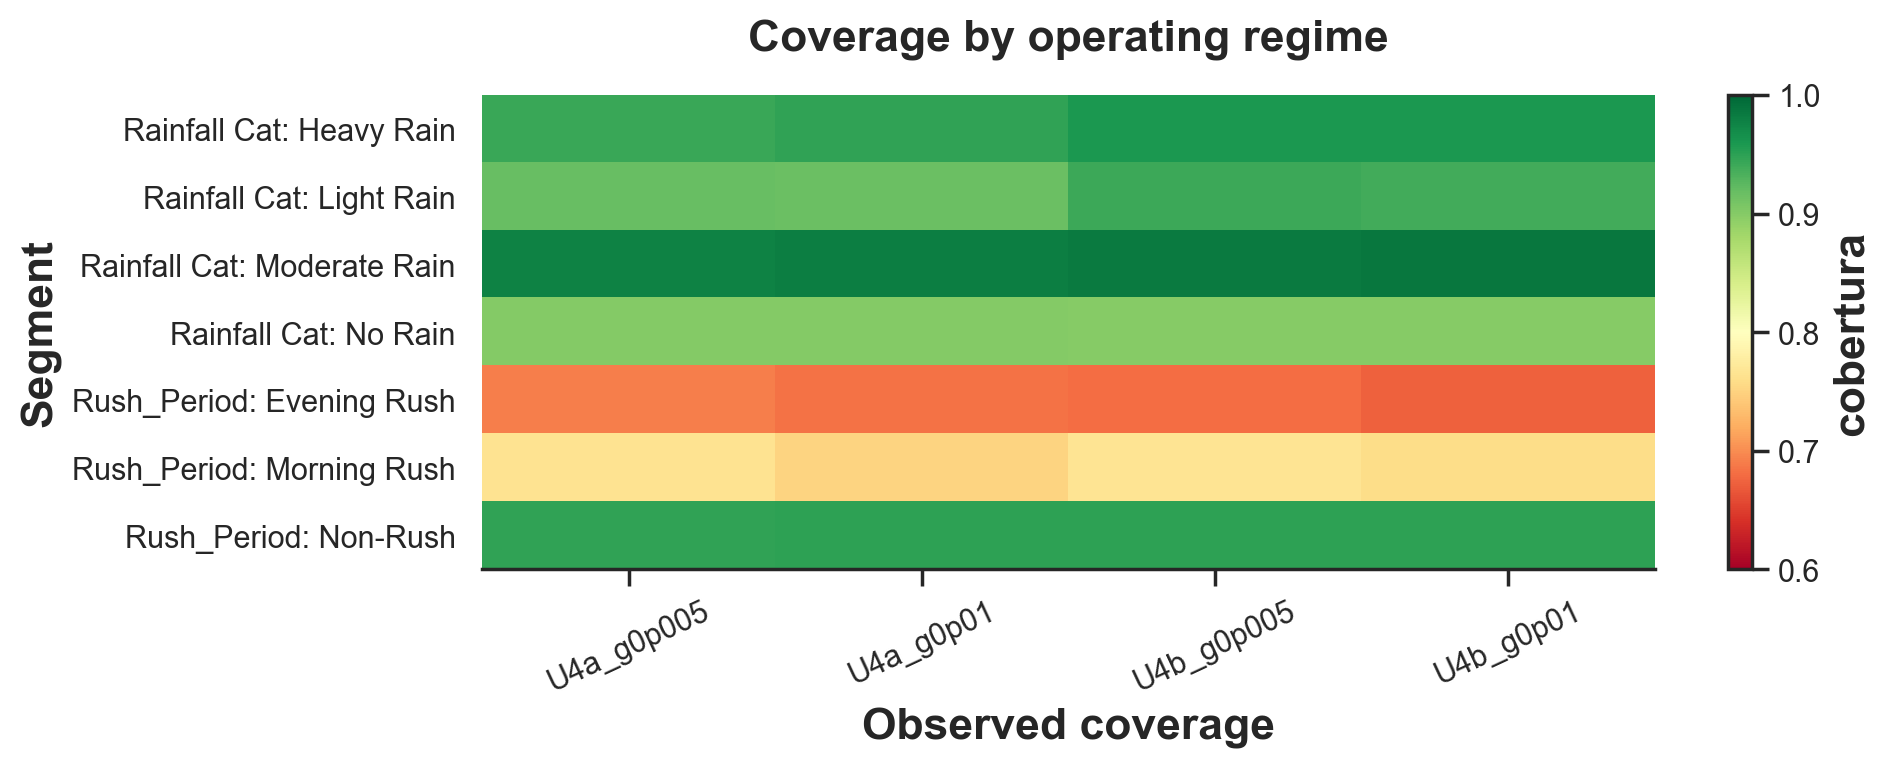

In [10]:
display(reports.segment_metrics_report(results, alerts_only=True, lang=lang))
reports.plot_segment_coverage(results, lang=lang)


## 13. Coverage, Sharpness and Winkler

The 80%, 90%, and 95% coverage targets are evaluated jointly. Because a complete predictive density was not constructed, NLL is not calculated; coverage, interval width, and the Winkler score are retained as distinct criteria for this layer.


,Candidate,Method,Nominal coverage,Calibrated folds,Observed coverage,Coverage error,Average width,Winkler score,Lower-tail violations,Upper-tail violations,Fallback rate
0,U5,U5,0.80,4,0.754362,-0.045638,1776.110804,3372.026416,0.097880,0.147758,0.177241
1,U1,U1,0.80,4,0.748286,-0.051714,1850.183201,3769.432889,0.099547,0.152167,0.000000
2,U4b_g0p01,U4b,0.80,4,0.803817,0.003817,2464.588824,3935.881643,0.070527,0.125656,0.000000
3,U4a_g0p01,U4a,0.80,4,0.804199,0.004199,2422.610448,3964.215719,0.068449,0.127352,0.000000
4,U4b_g0p005,U4b,0.80,4,0.804750,0.004750,2471.082843,3970.065540,0.069314,0.125936,0.000000
5,U4a_g0p005,U4a,0.80,4,0.804883,0.004883,2421.776515,3996.909770,0.067352,0.127765,0.000000
6,U2_h168,U2,0.80,4,0.792084,-0.007916,2346.188340,4029.057201,0.070197,0.137719,0.000000
7,U4b_g0p001,U4b,0.80,4,0.806029,0.006029,2531.673722,4048.253118,0.065526,0.128444,0.000000
8,U4a_g0p001,U4a,0.80,4,0.804832,0.004832,2476.438669,4073.327248,0.063664,0.131504,0.000000
9,U2_h720,U2,0.80,4,0.766517,-0.033483,2234.591700,4164.914078,0.076817,0.156666,0.000000


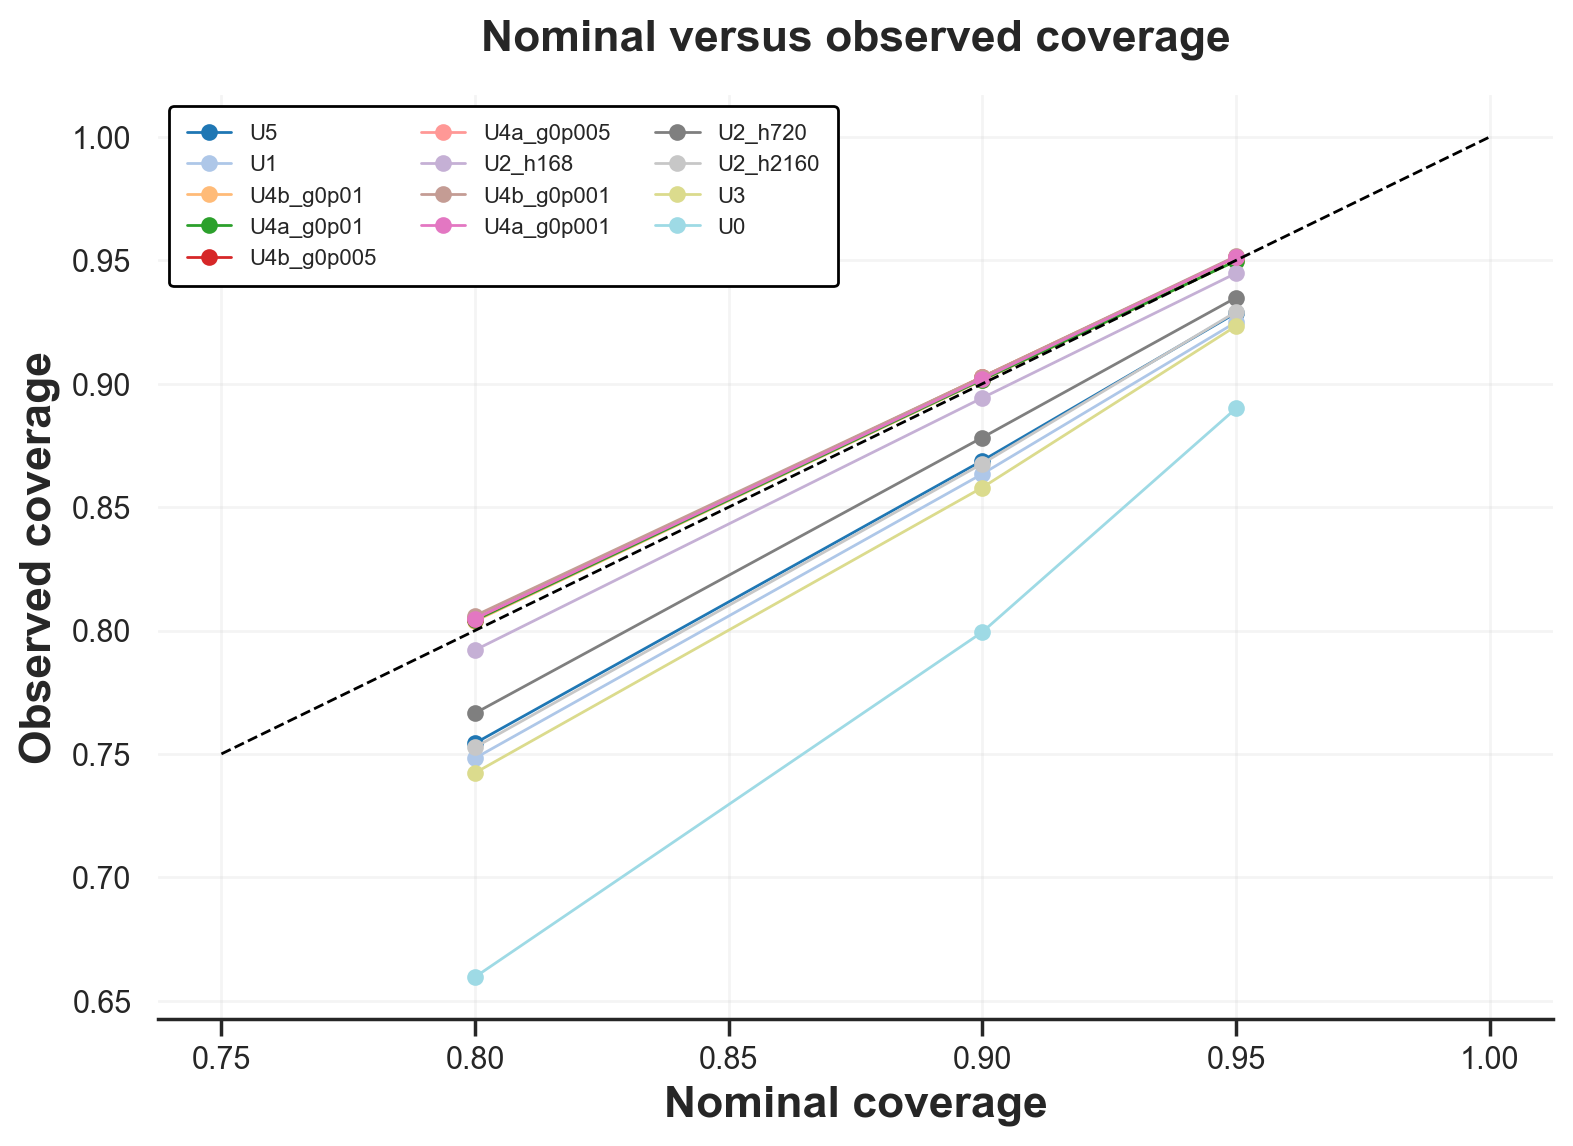

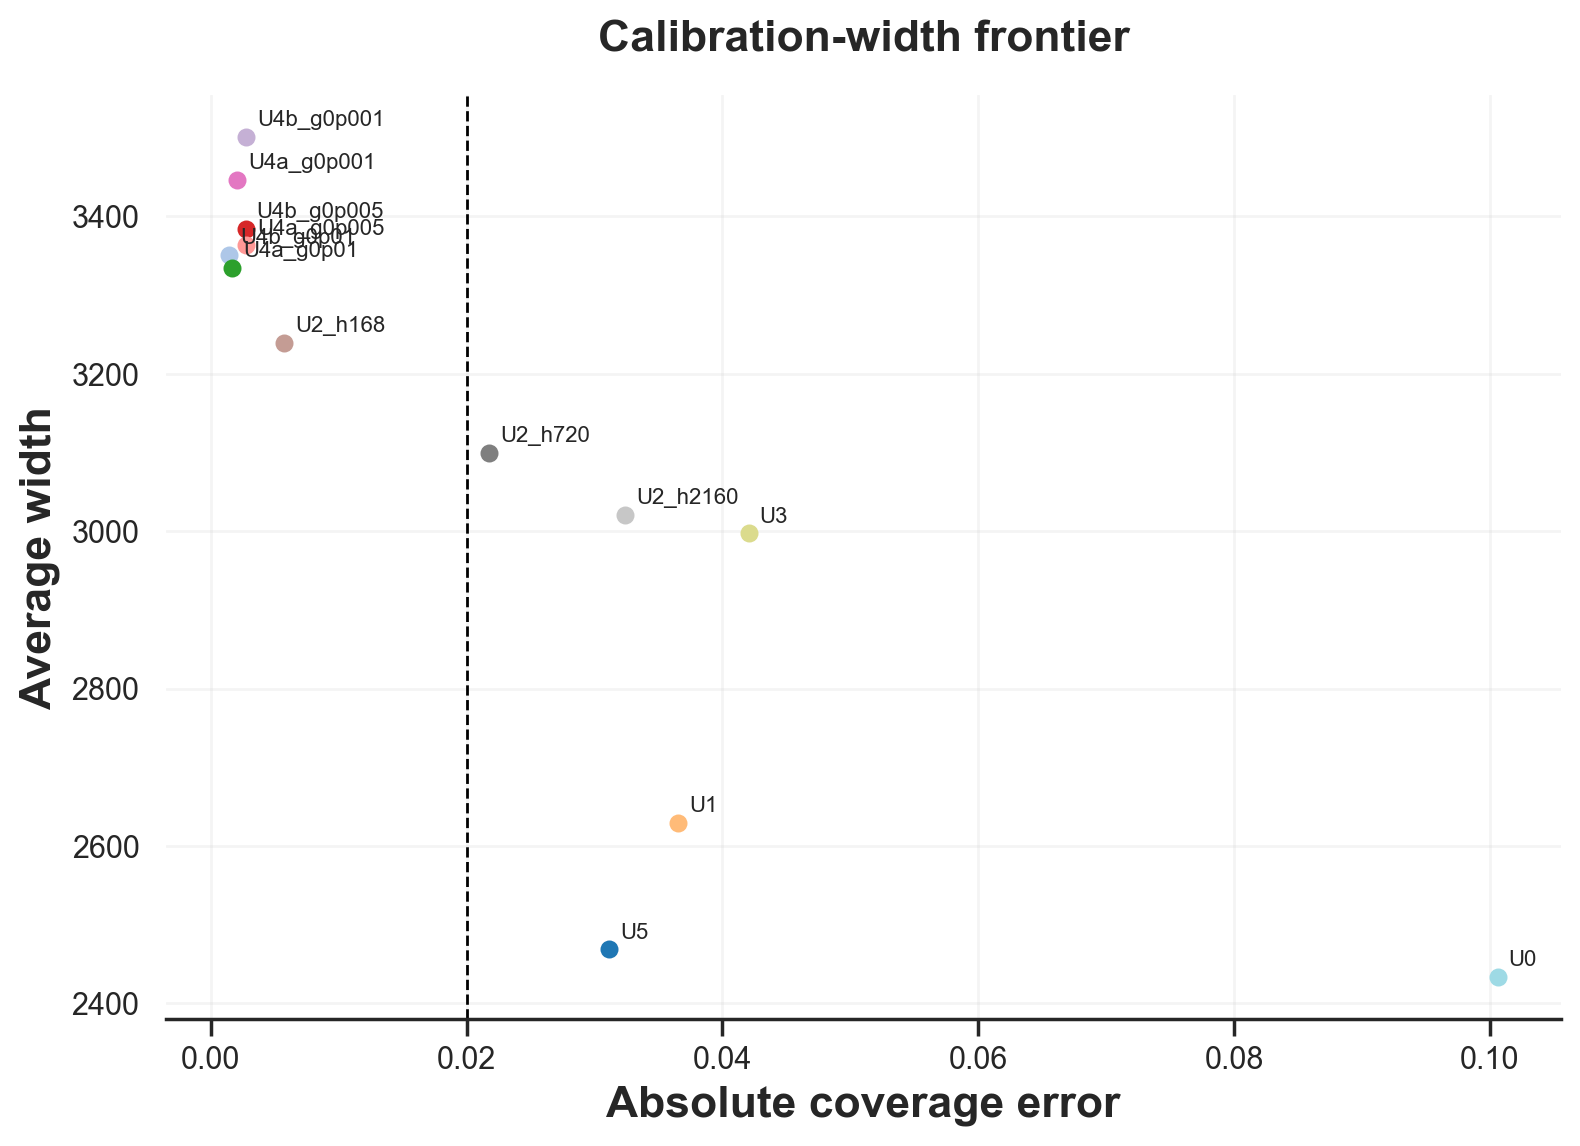

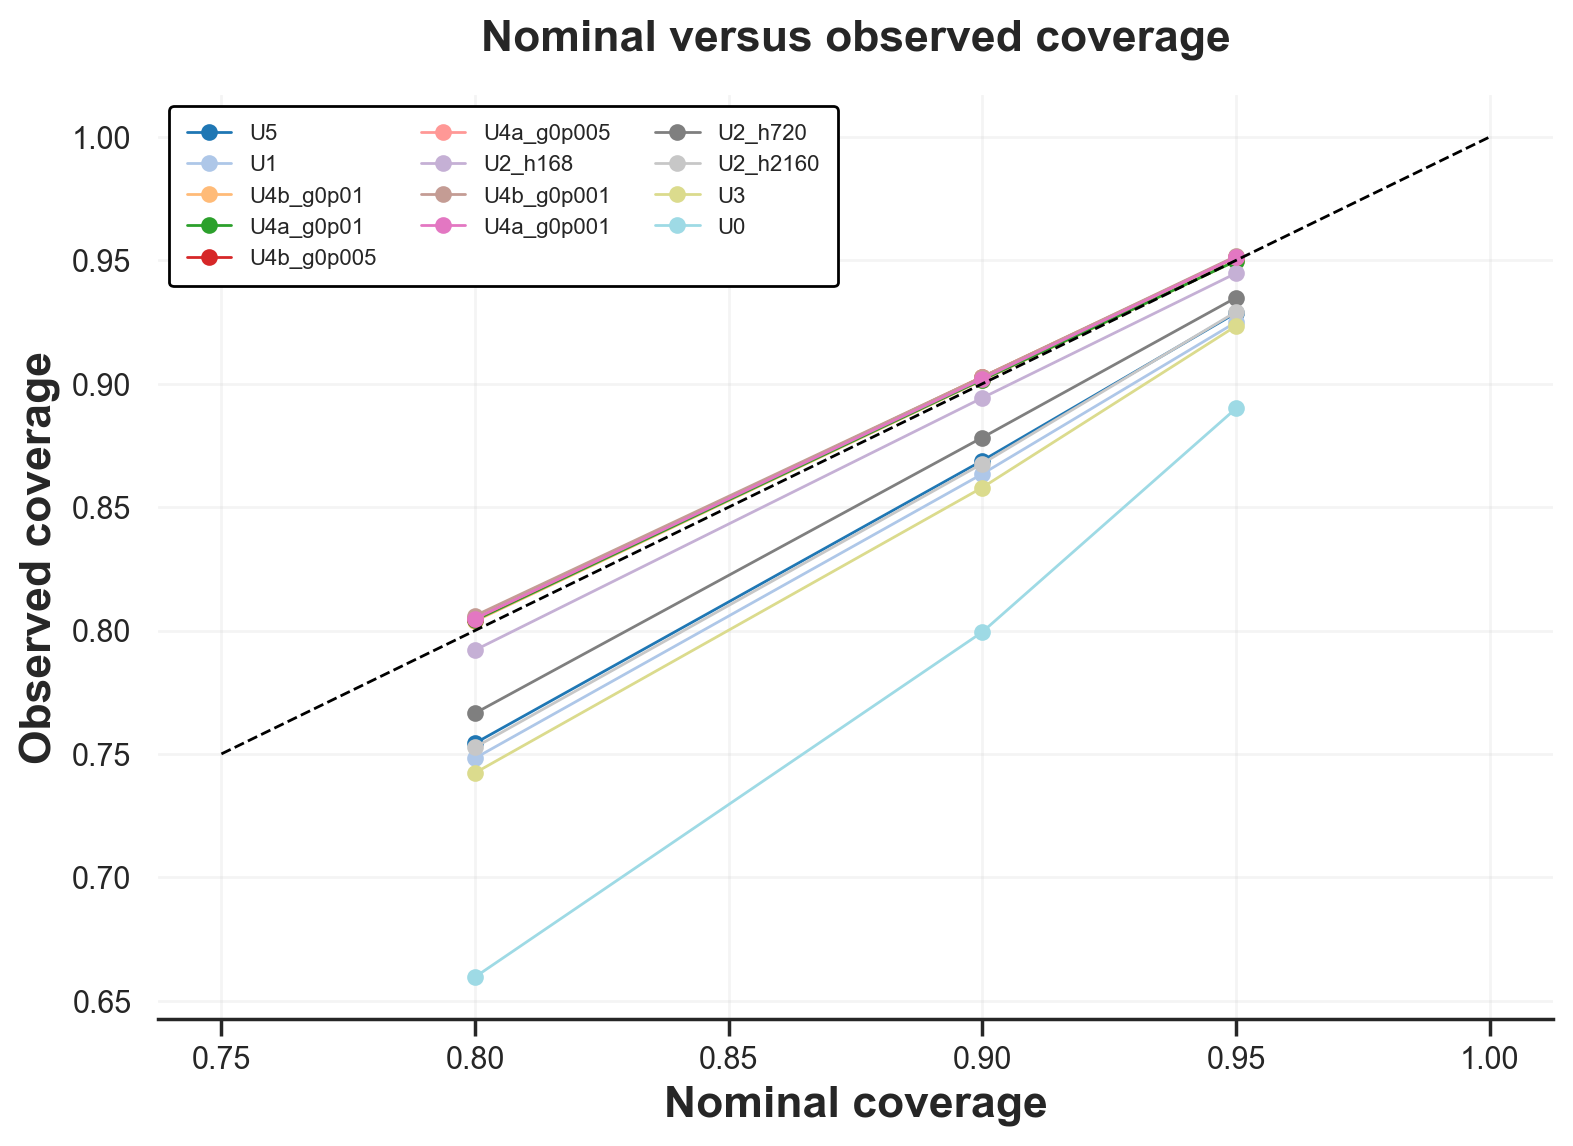

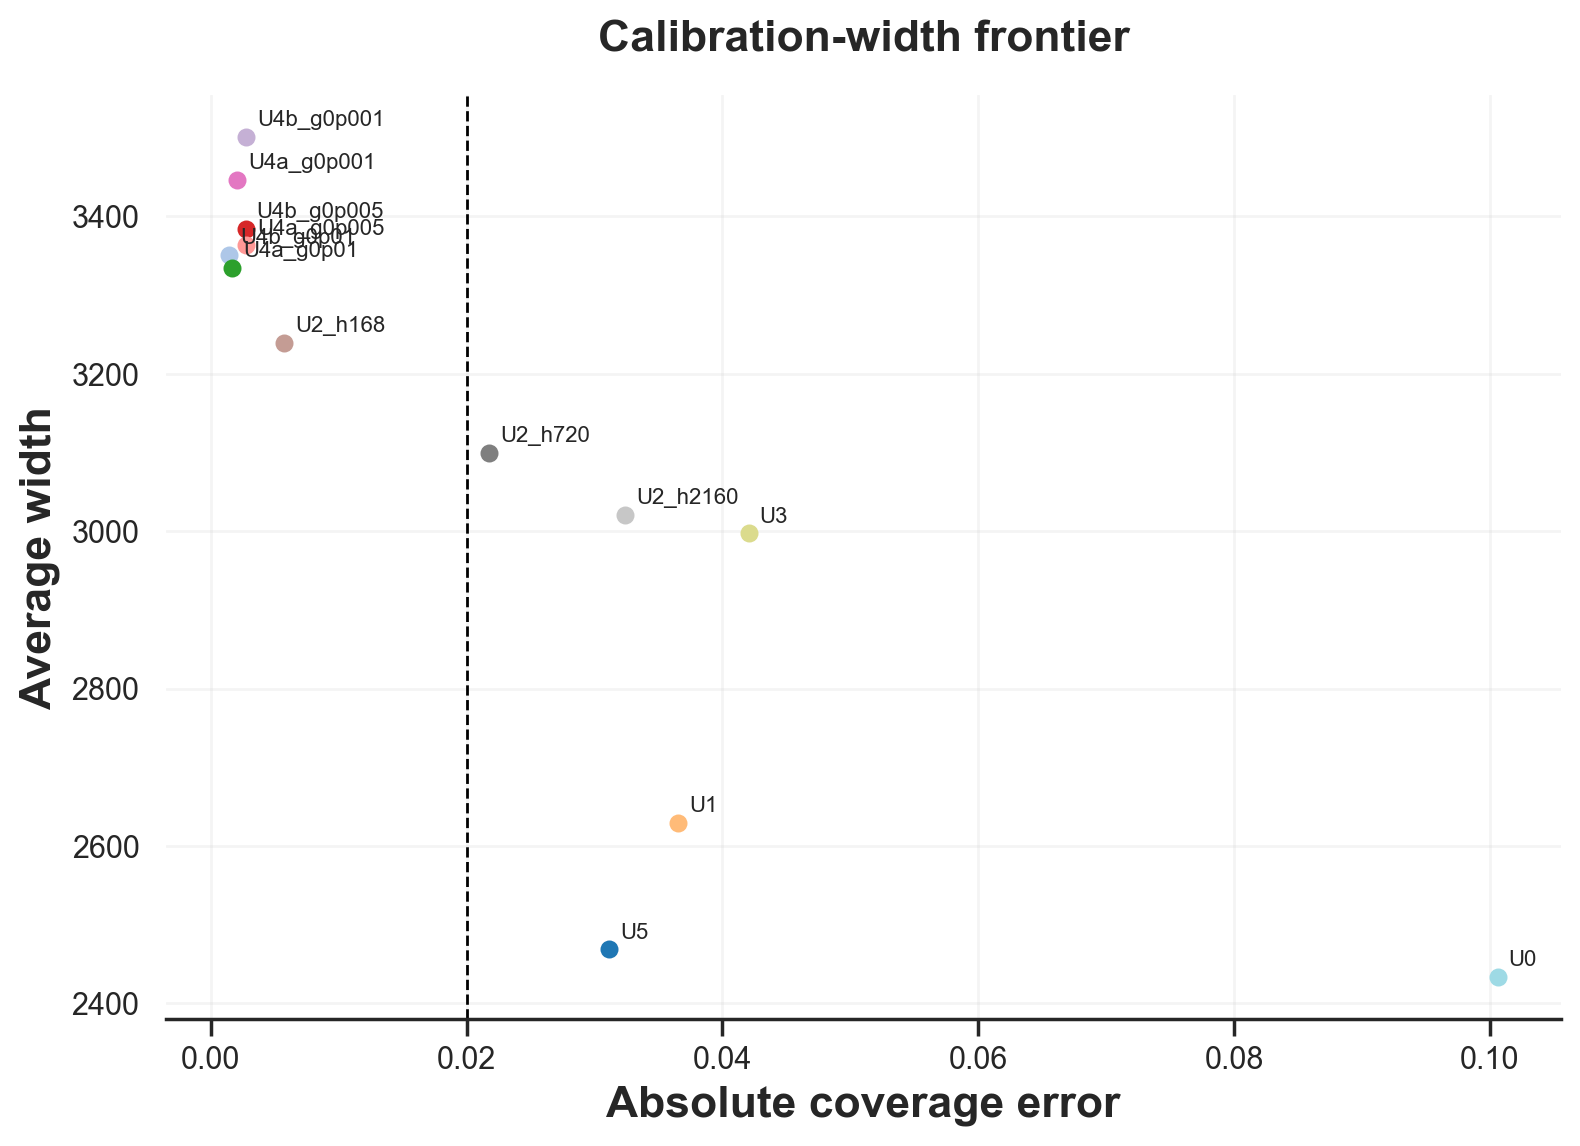

In [11]:
display(reports.aggregate_metrics_report(results, lang=lang))
display(reports.plot_coverage_calibration(results, lang=lang))
reports.plot_coverage_width_pareto(results, lang=lang)


## 14. Stability Across Folds and Time

Coverage is examined by fold and over rolling windows of 168 and 720 hours. This prevents an apparently adequate aggregate average from concealing prolonged periods of undercoverage.


,Candidate,Nominal coverage,Fold,Meteorological year,Scored observations,Observed coverage,Coverage error,Average width,Winkler score,Fallback rate,Longest miss streak
0,U0,0.80,1,2019,8547,0.593074,-0.206926,919.256664,2927.245779,0.000000,23
1,U0,0.90,1,2019,8547,0.764830,-0.135170,1366.623656,3662.869022,0.000000,20
2,U0,0.95,1,2019,8547,0.872821,-0.077179,1850.219562,4303.252912,0.000000,13
6,U0,0.80,3,2021,8592,0.756634,-0.043366,2328.483861,4259.117668,0.000000,18
7,U0,0.90,3,2021,8592,0.869646,-0.030354,3065.076996,5256.004796,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...
190,U5,0.90,4,2022,8591,0.863927,-0.036073,2599.043963,4583.858388,0.172506,15
191,U5,0.95,4,2022,8591,0.928297,-0.021703,3443.213435,5568.982857,0.172506,9
192,U5,0.80,5,2023,8592,0.760242,-0.039758,1844.239483,3627.048820,0.183077,19
193,U5,0.90,5,2023,8592,0.874069,-0.025931,2629.990400,4714.560877,0.183077,13


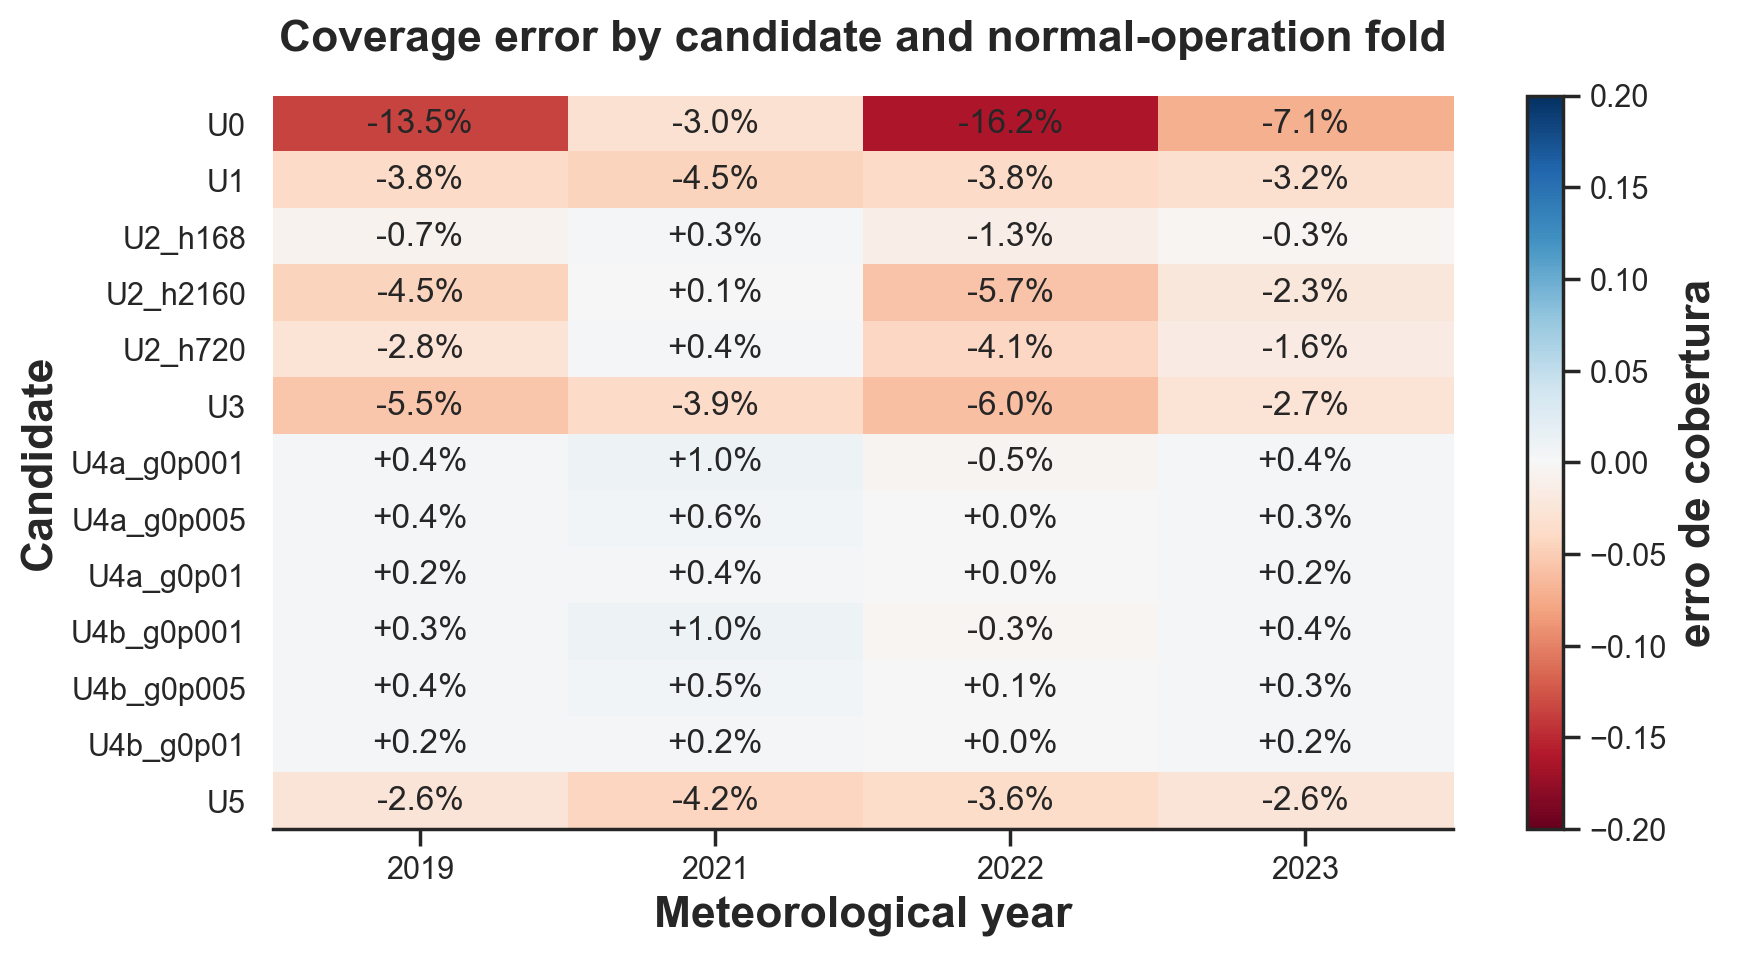

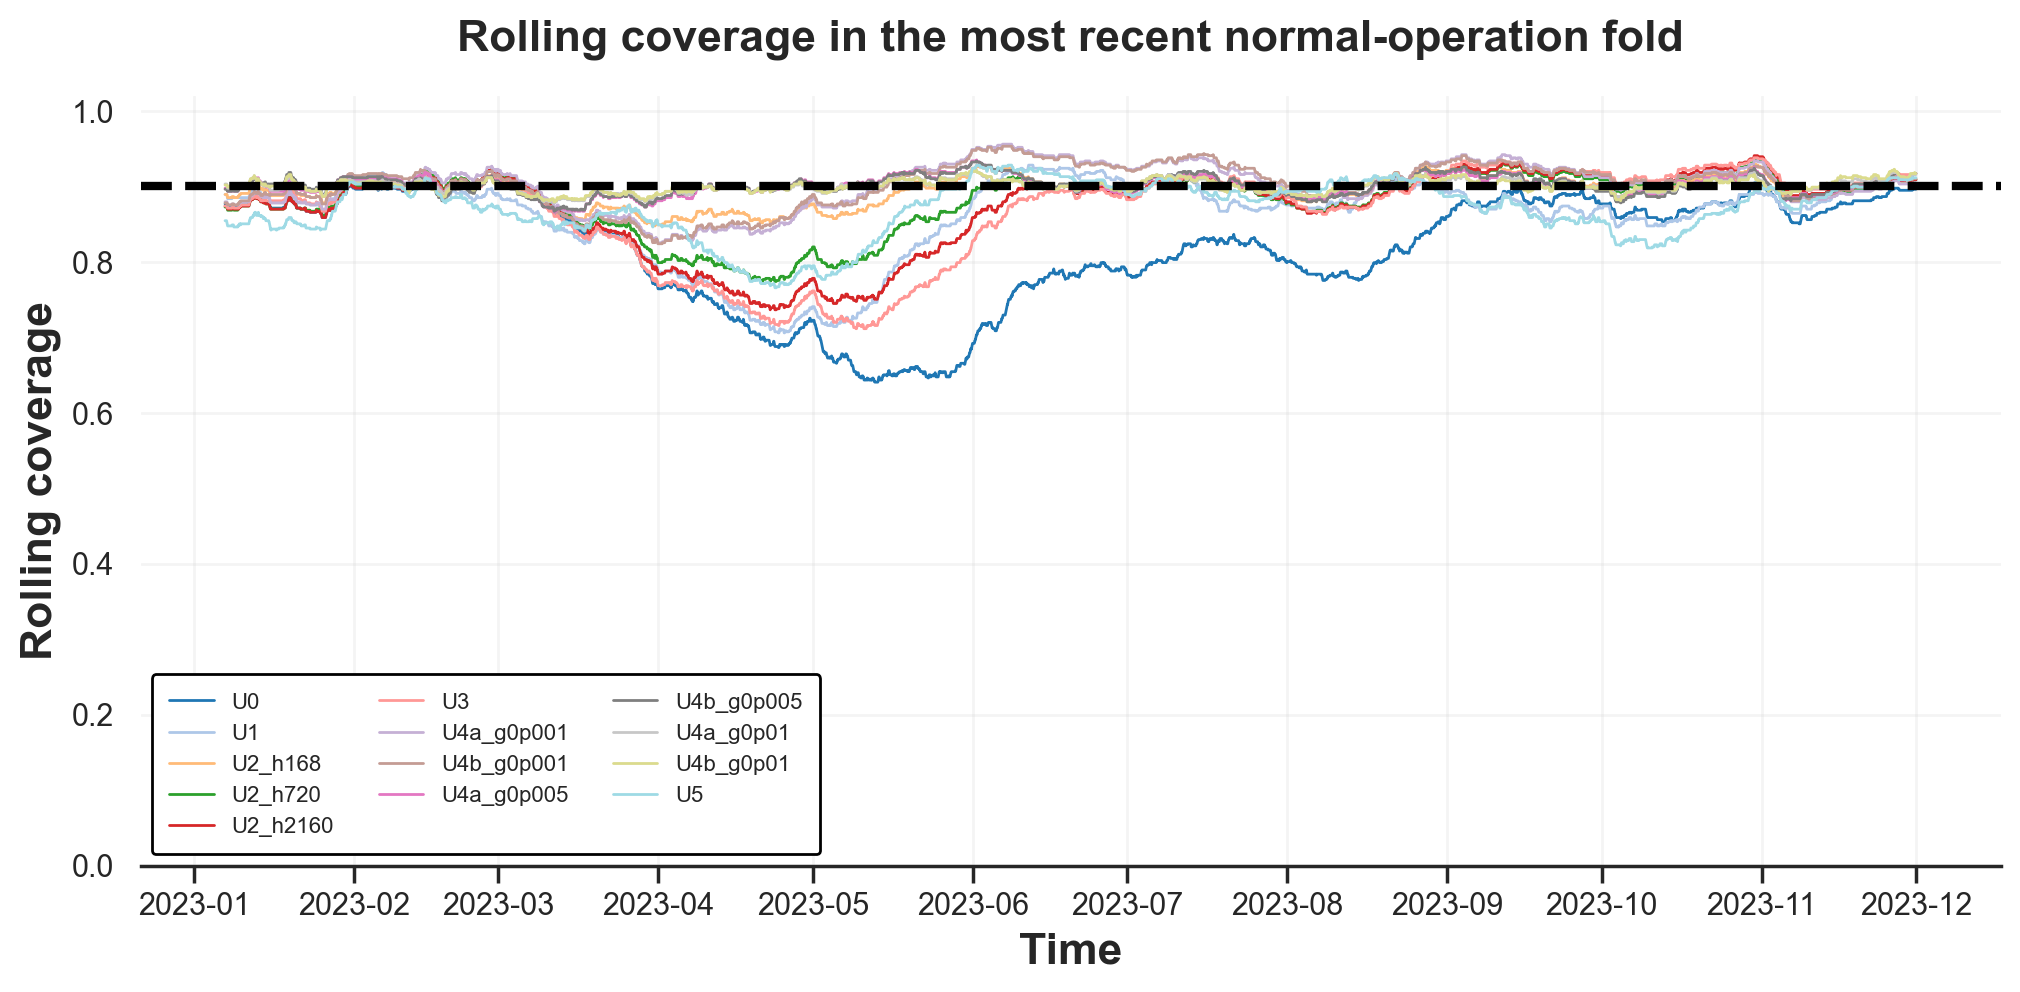

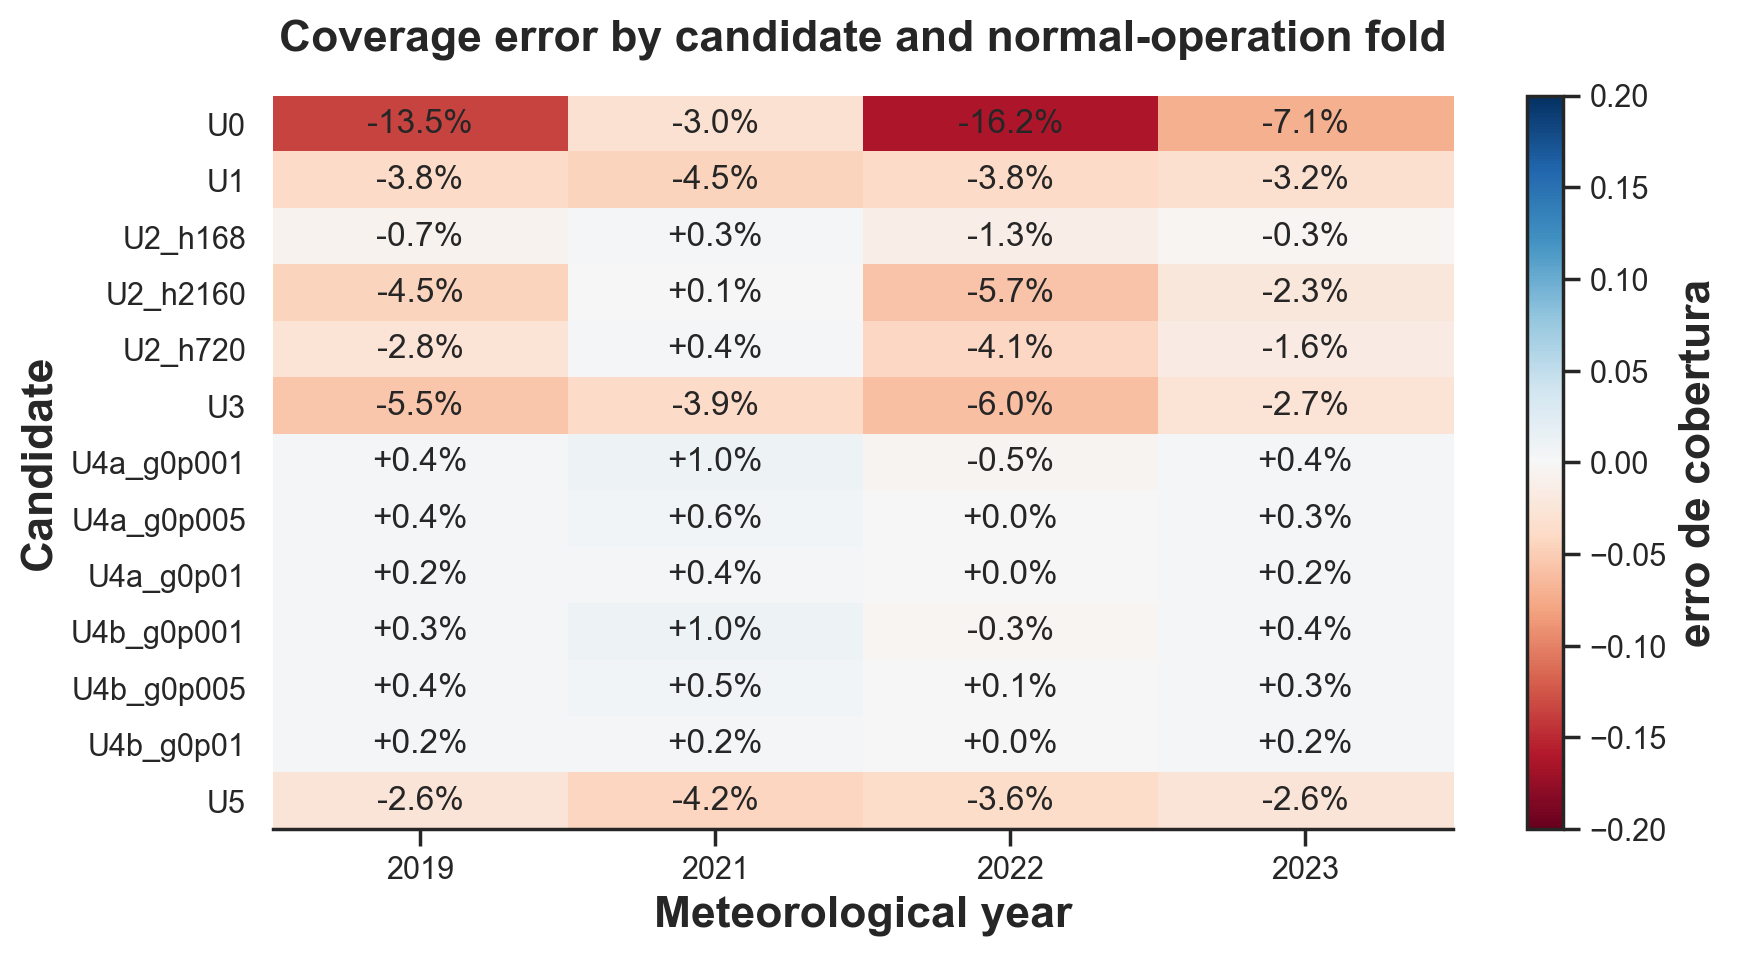

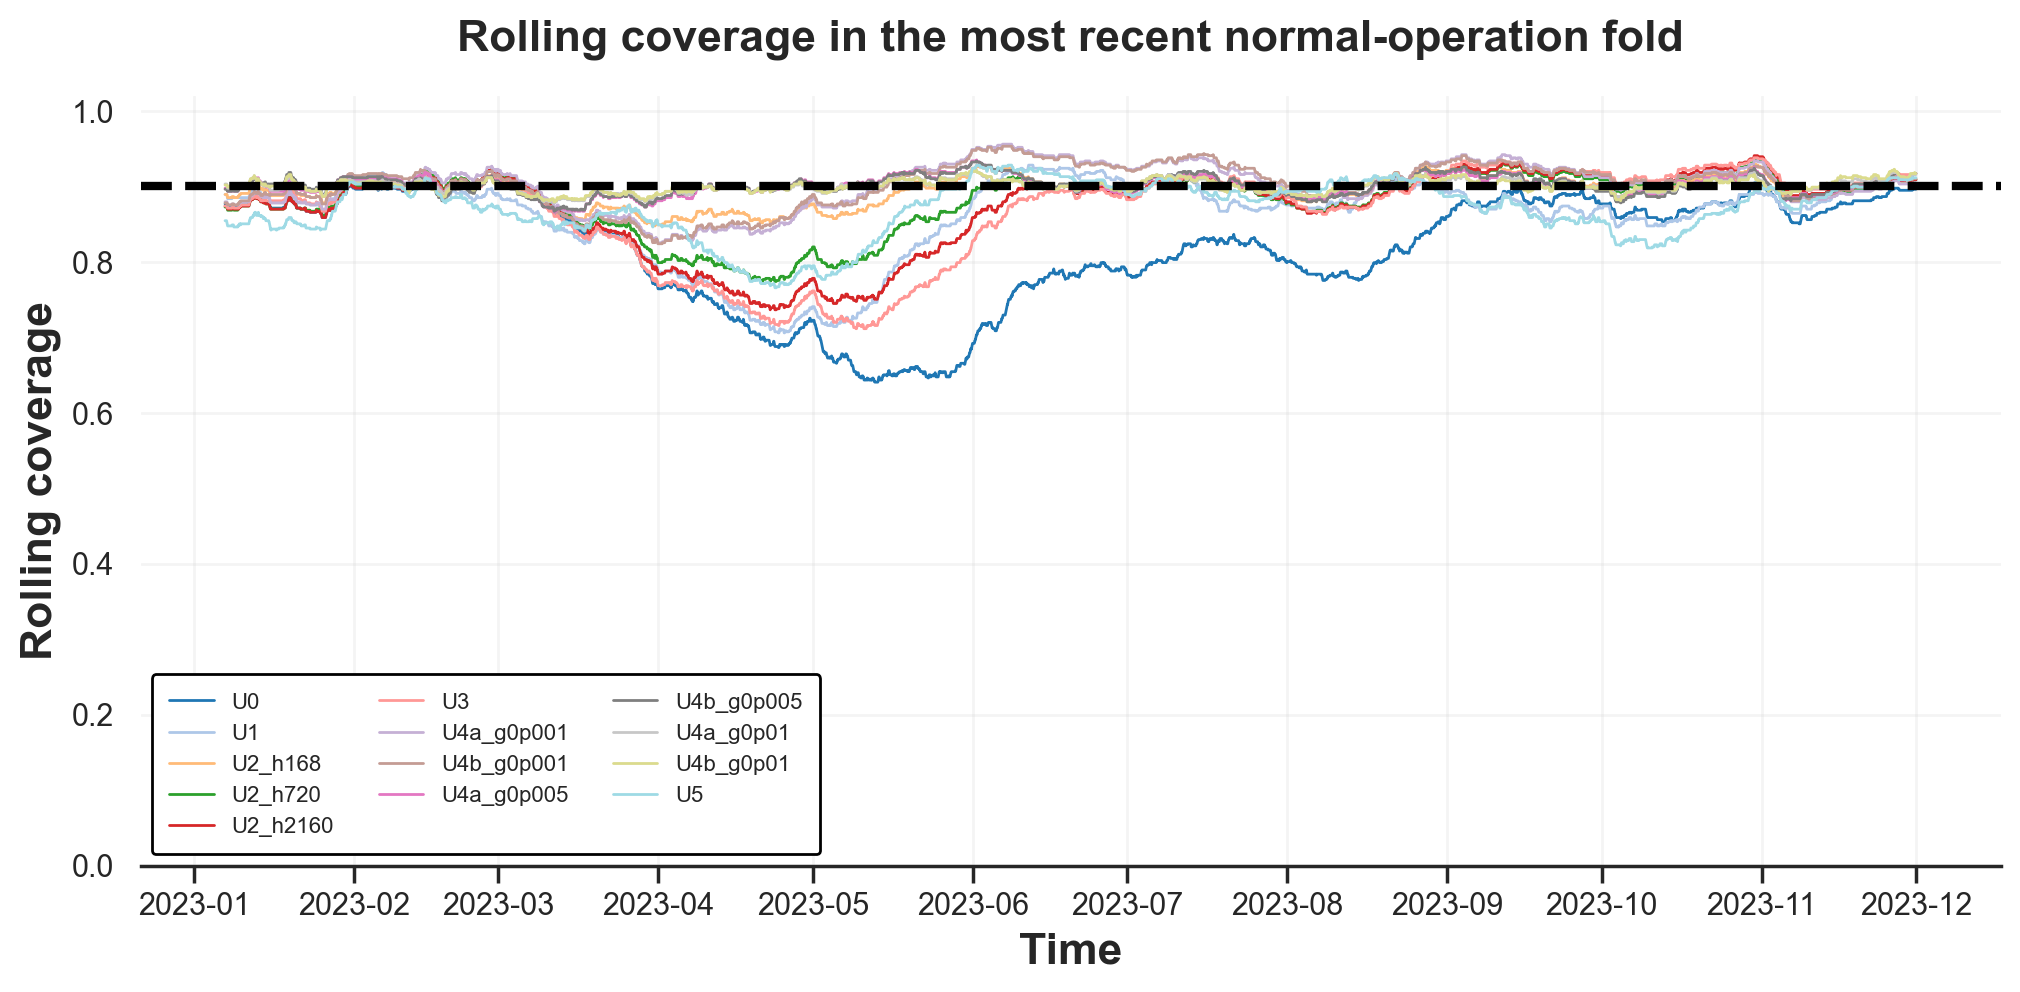

In [12]:
display(reports.fold_metrics_report(results, lang=lang))
display(reports.plot_fold_coverage_heatmap(results, lang=lang))
reports.plot_rolling_coverage(results, lang=lang)


## 15. Stress de 2020

The 2020 regime is presented exclusively as a stress scenario. Its state is reset, its results are excluded from the ranking, and no residual from this period is transferred to subsequent normal-operation folds.


In [13]:
reports.stress_metrics_report(results, lang=lang)


,Candidate,Nominal coverage,Stress year,Scored observations,Stress coverage,Coverage error,Average width,Winkler score
0,U0,0.80,2020,8591,0.530672,-0.269328,2289.958551,8142.771539
1,U0,0.90,2020,8591,0.713770,-0.186230,3320.406146,9851.174818
2,U0,0.95,2020,8591,0.823653,-0.126347,4237.986528,11249.137396
3,U1,0.80,2020,8591,0.714934,-0.085066,1505.893920,3471.489681
4,U1,0.90,2020,8591,0.841811,-0.058189,1850.347639,4019.164266
5,U1,0.95,2020,8591,0.915027,-0.034973,2219.355506,4651.629240
6,U2_h168,0.80,2020,8591,0.777325,-0.022675,3839.073071,5784.429878
7,U2_h168,0.90,2020,8591,0.883948,-0.016052,4734.918038,6524.297689
8,U2_h168,0.95,2020,8591,0.941450,-0.008550,5397.596261,7336.241898
9,U2_h720,0.80,2020,8591,0.717728,-0.082272,3603.958630,6188.972931


## 16. Decisão Experimental

The primary gate requires an aggregated coverage error of no more than two percentage points and prevents the worst fold from being more than five points below the nominal. Among viable candidates, Winkler, width, stability, and fallback are ordered in this sequence.

Bootstrap in weekly blocks is used to express the uncertainty of the aggregated coverage without crossing folds.


,Candidate,Nominal coverage,Observed coverage,Lower 95% CI,Upper 95% CI,Replications,Block size (hours)
0,U0,0.9,0.799396,0.779503,0.816951,500,168
1,U1,0.9,0.863453,0.850075,0.873687,500,168
2,U2_h168,0.9,0.894270,0.887347,0.900429,500,168
3,U2_h720,0.9,0.878209,0.866195,0.887006,500,168
4,U2_h2160,0.9,0.867621,0.853955,0.877974,500,168
5,U3,0.9,0.857953,0.842922,0.869693,500,168
6,U4a_g0p001,0.9,0.902059,0.892213,0.908786,500,168
7,U4b_g0p001,0.9,0.902758,0.892014,0.910376,500,168
8,U4a_g0p005,0.9,0.902775,0.895461,0.907893,500,168
9,U4b_g0p005,0.9,0.902725,0.895913,0.907979,500,168


,Candidate,Method,Observed coverage,Coverage error,Worst fold coverage,Winkler score,Average width,Across-fold standard deviation,Fallback rate,Segment alerts,Coverage gate,Experimental ranking
0,U4b_g0p01,U4b,0.901460,0.001460,0.900244,4836.901802,3351.031061,0.000822,0.000000,4,True,1.0
1,U4a_g0p01,U4a,0.901659,0.001659,0.900012,4895.725881,3334.975219,0.001547,0.000000,4,True,2.0
2,U4b_g0p005,U4b,0.902725,0.002725,0.900710,4901.799832,3383.733688,0.001496,0.000000,4,True,3.0
3,U4a_g0p005,U4a,0.902775,0.002775,0.900128,4956.182449,3363.234155,0.002050,0.000000,4,True,4.0
4,U4b_g0p001,U4b,0.902758,0.002758,0.896636,5021.338938,3500.802718,0.004711,0.000000,4,True,5.0
5,U2_h168,U2,0.894270,-0.005730,0.886742,5021.881360,3239.474294,0.006025,0.000000,4,True,6.0
6,U4a_g0p001,U4a,0.902059,0.002059,0.894657,5088.844671,3445.978002,0.005410,0.000000,4,True,7.0
7,U5,U5,0.868849,-0.031151,0.857542,4290.803280,2468.440523,0.007104,0.177241,3,False,NaN
8,U1,U1,0.863453,-0.036547,0.854749,4860.317600,2629.141214,0.004590,0.000000,5,False,NaN
9,U2_h720,U2,0.878209,-0.021791,0.859155,5240.044560,3099.351328,0.016624,0.000000,4,False,NaN


'Candidate U4b_g0p01 was the most defensible experimental calibrator: 90.1% coverage, +0.15% error, average width of 3,351.0, and a Winkler score of 4,836.9. A new independent window is still required before any operational adoption.'

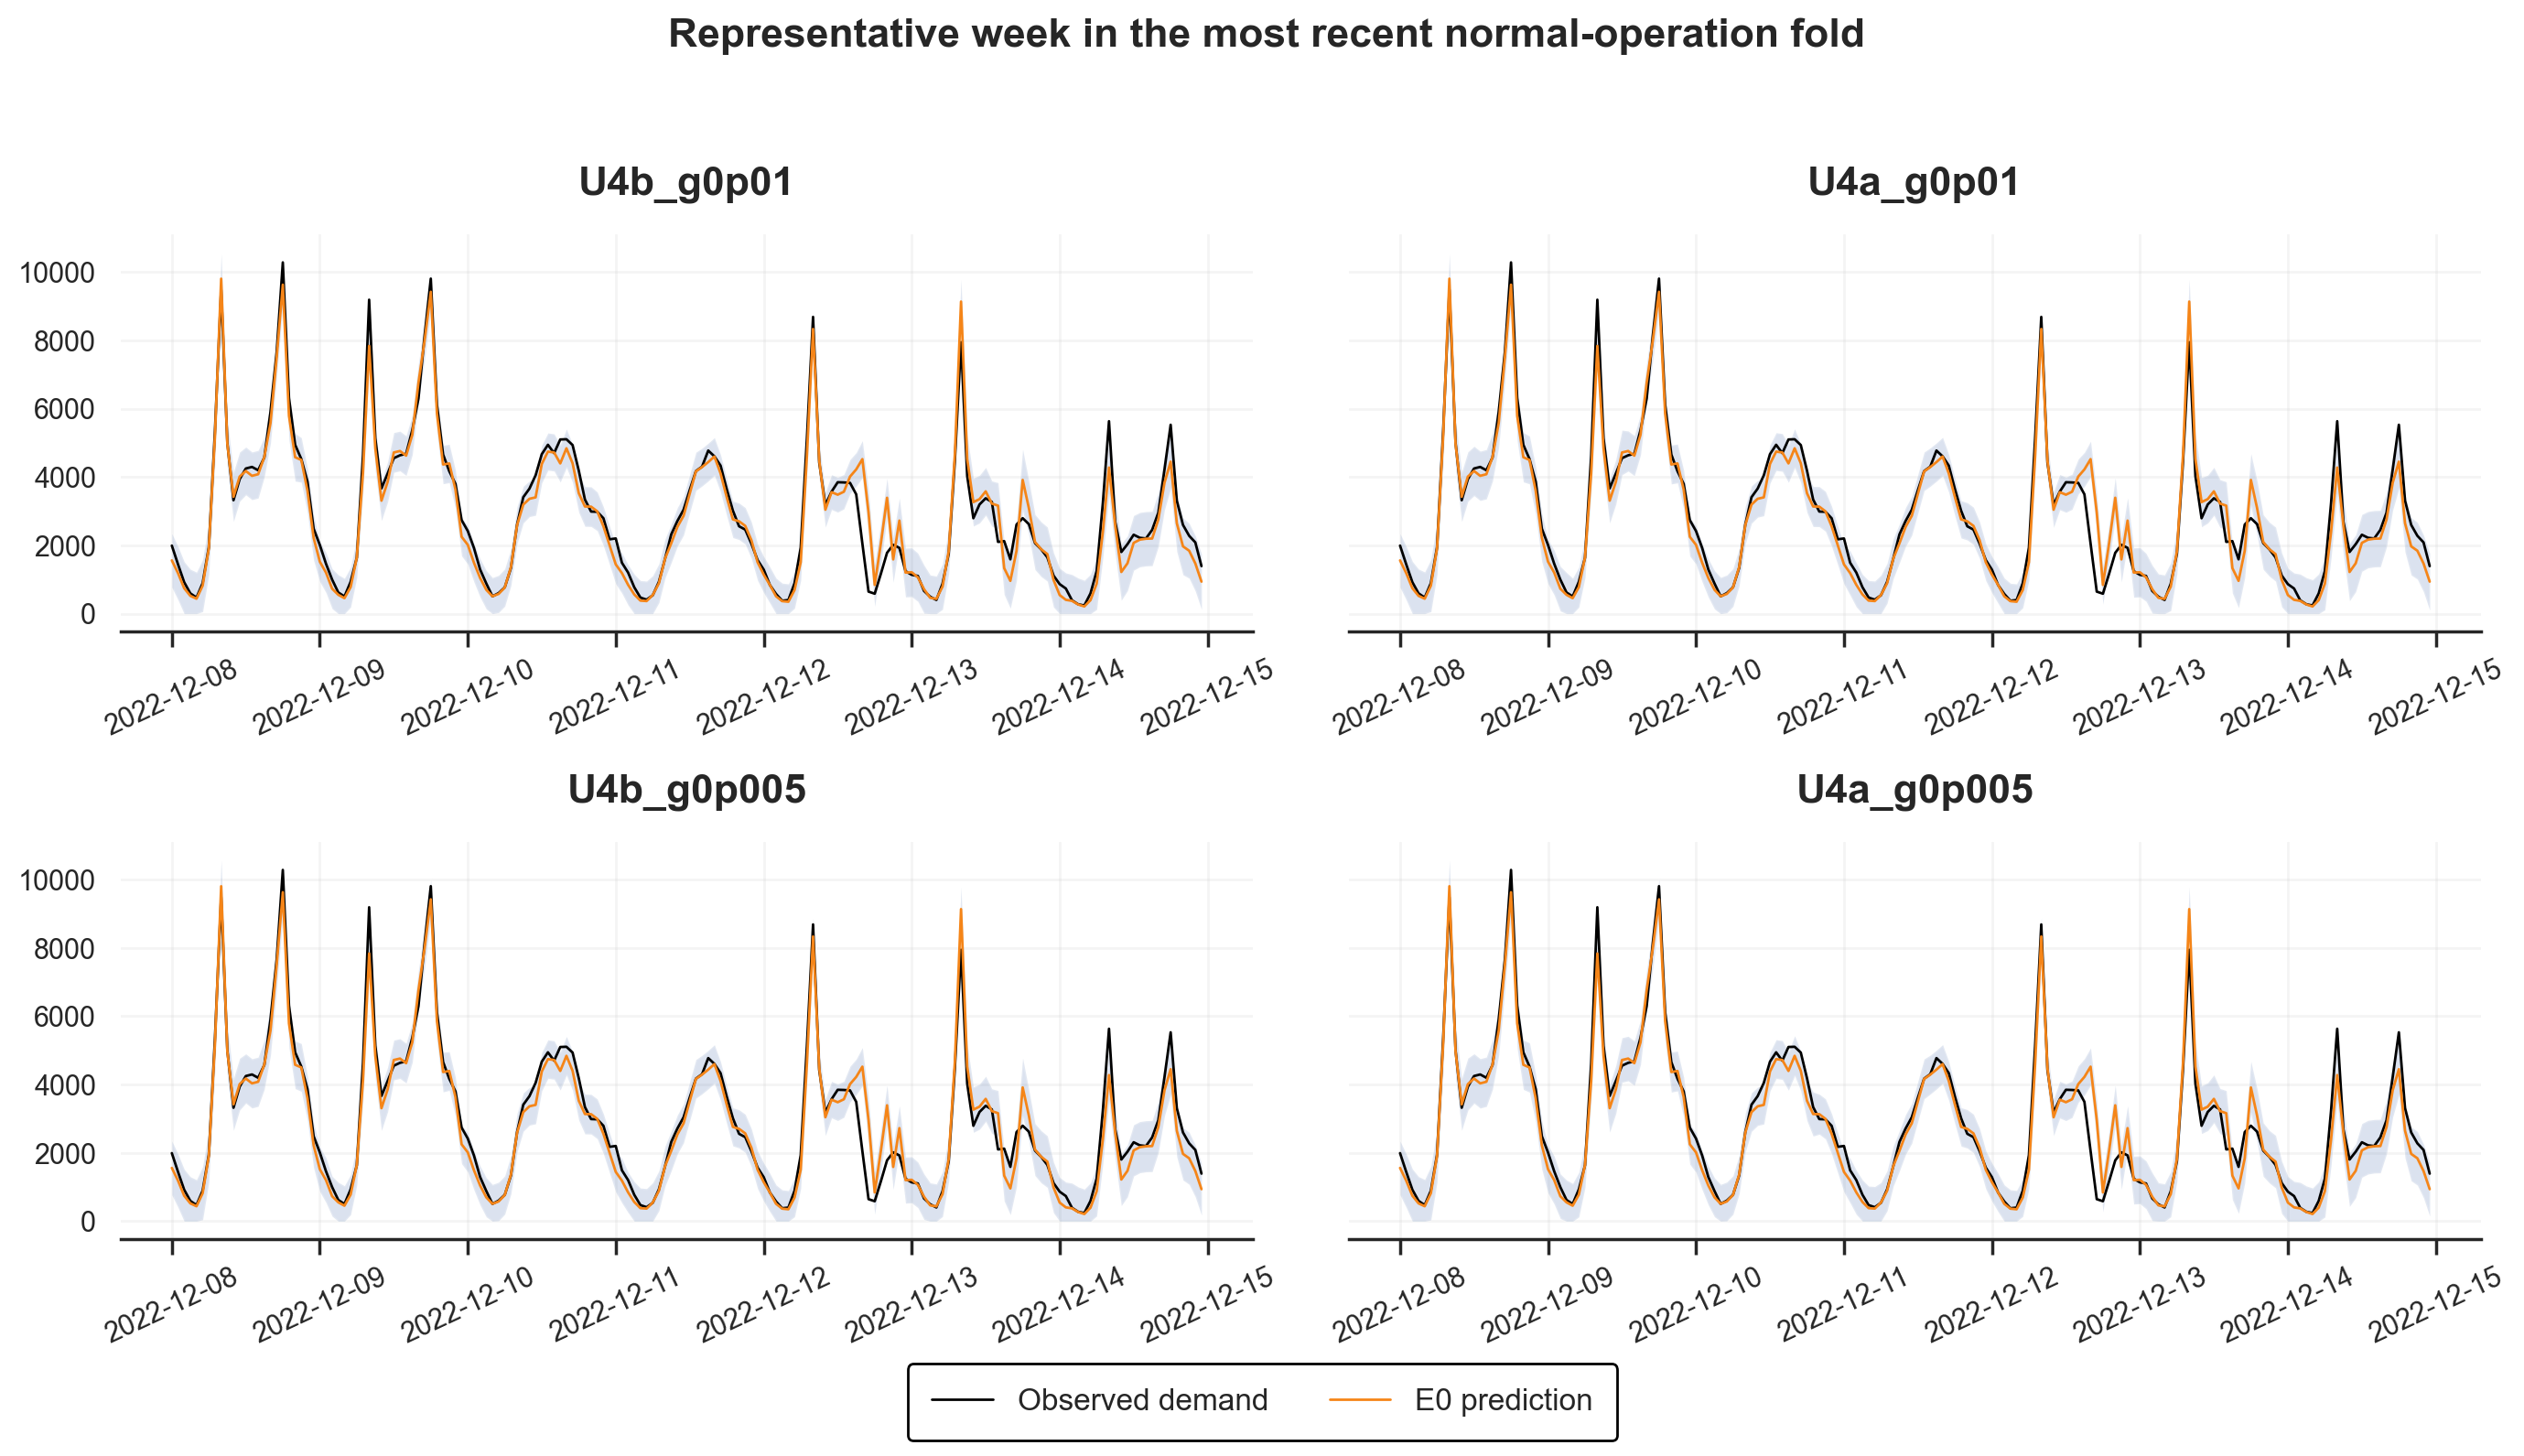

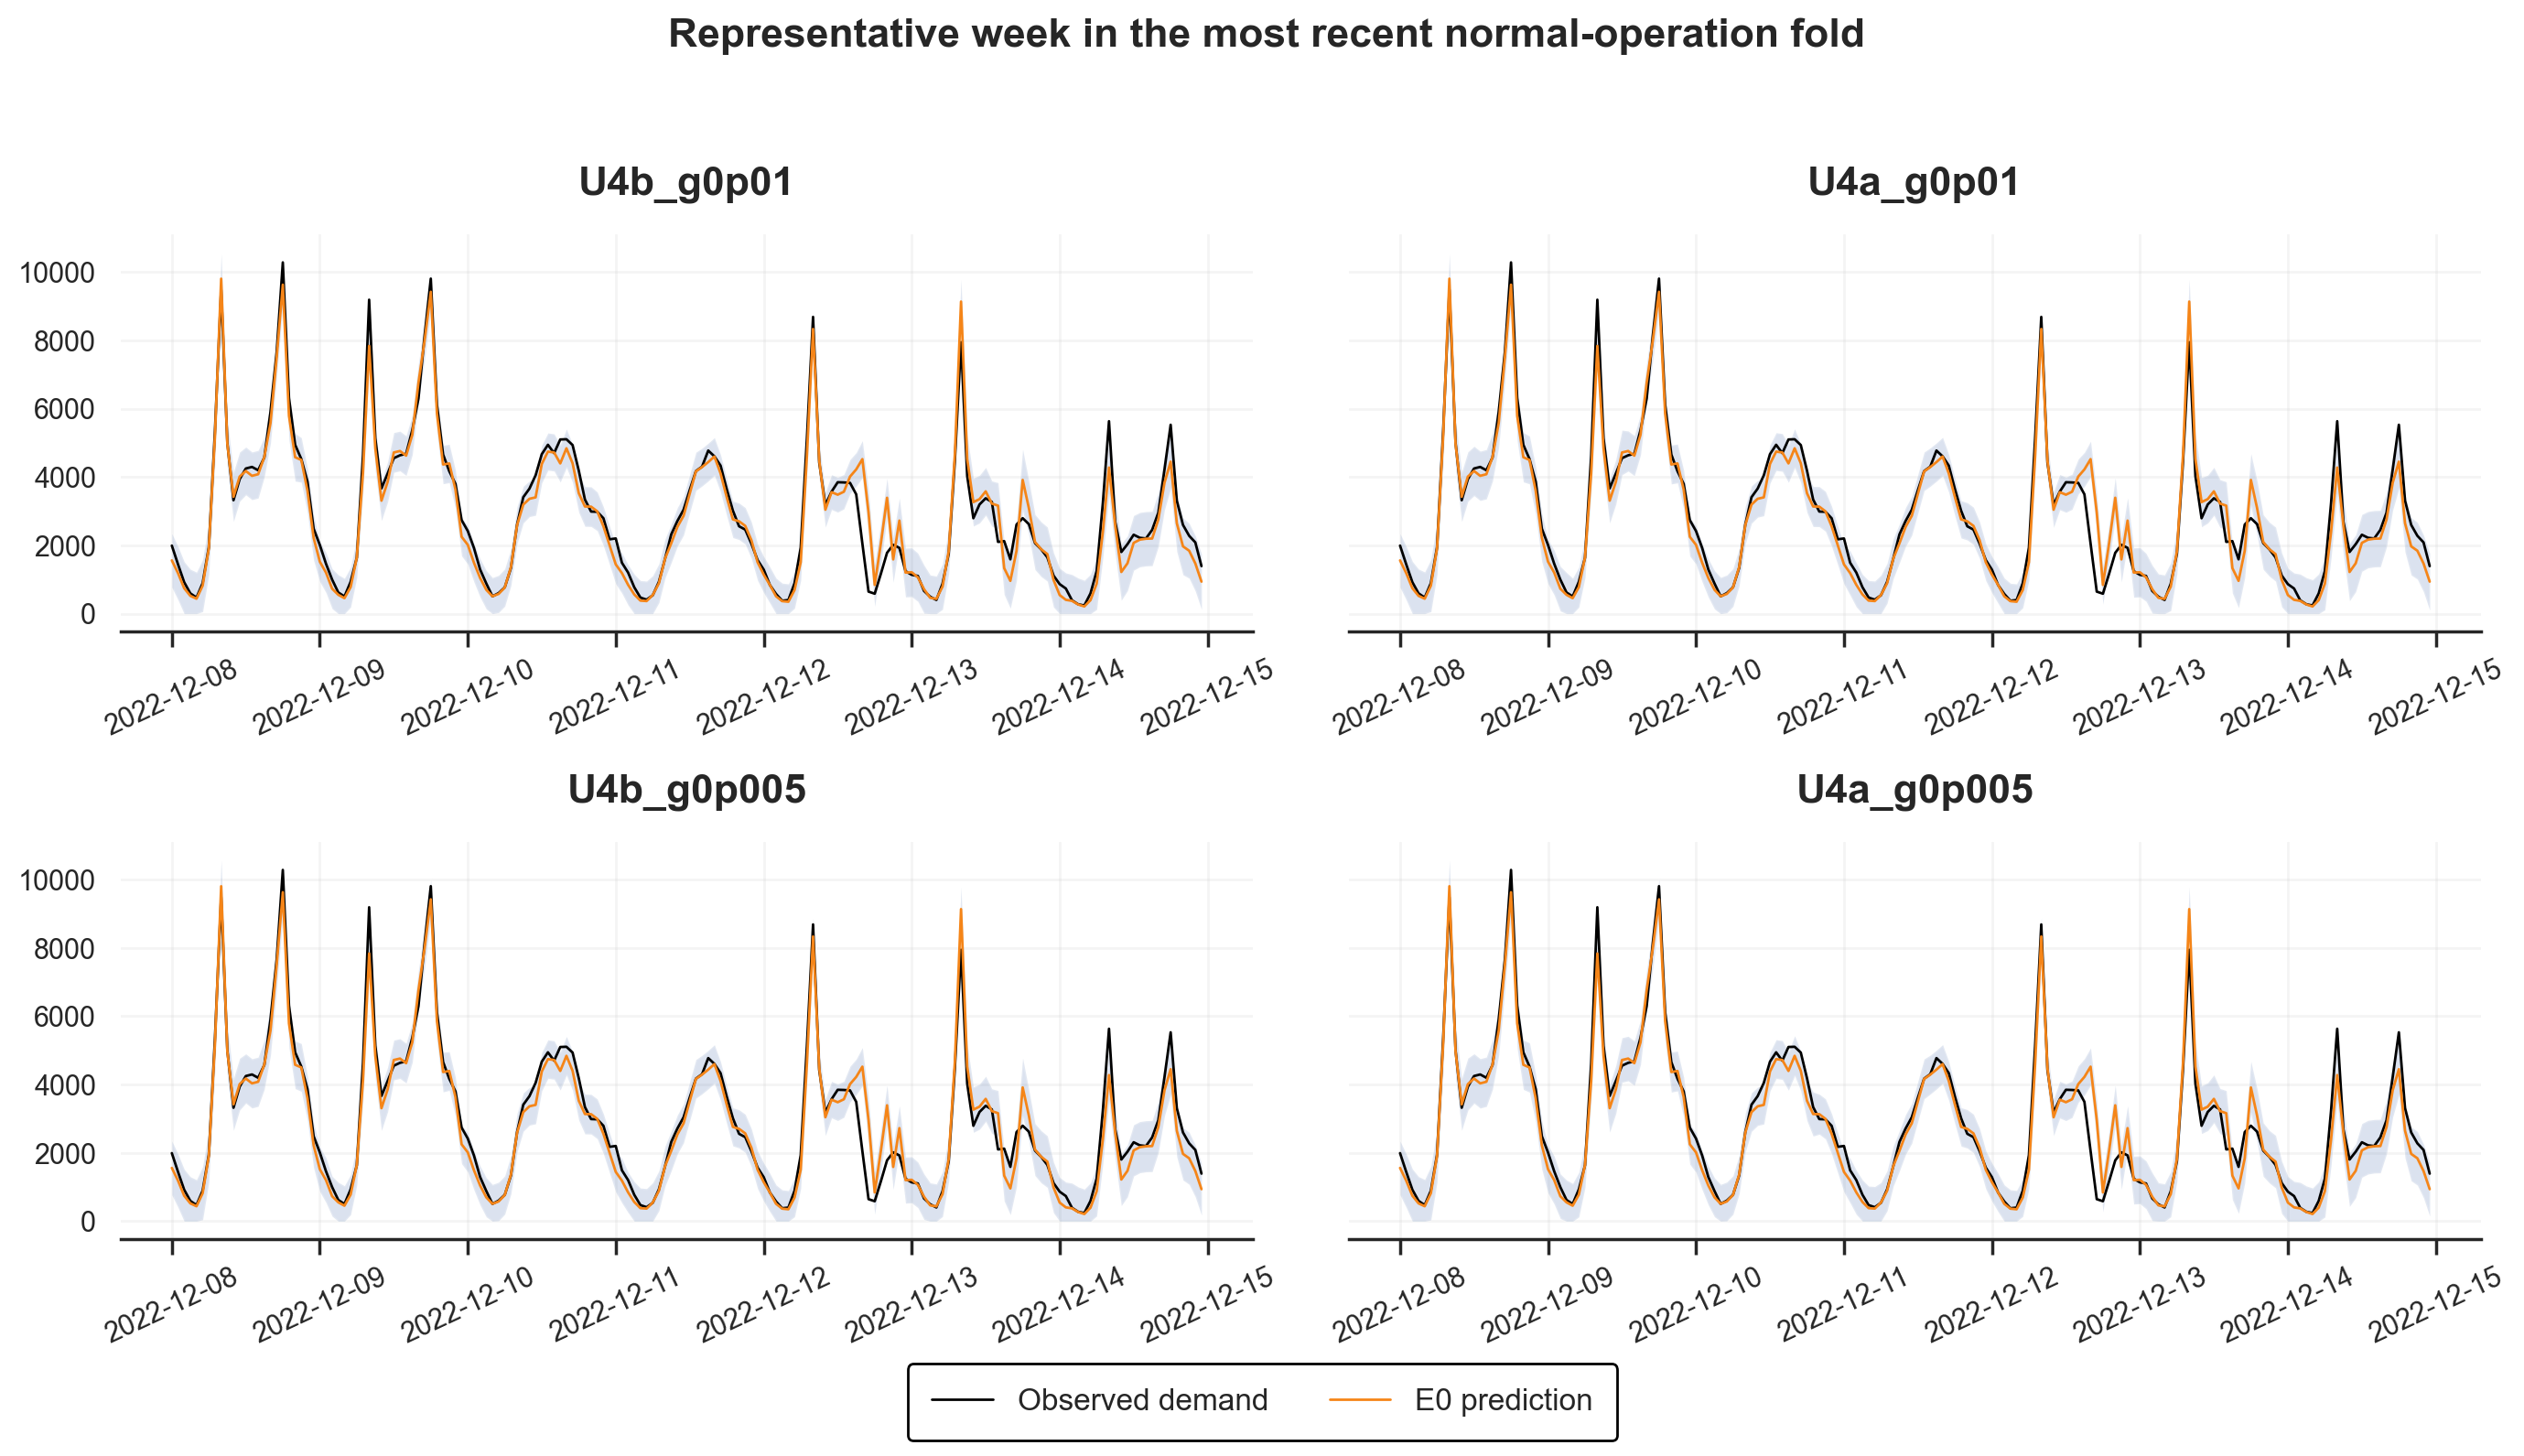

In [14]:
display(reports.bootstrap_report(results, lang=lang))
display(reports.decision_report(results, lang=lang))
display(reports.calibration_message(results, lang=lang))
reports.plot_representative_interval_windows(results, lang=lang)


### Insights

>During the `full` execution, 34,322 observations from the four operational folds were scored after the 168-hour *warm-up* in each window. U4b with `gamma=0.01` (`U4b_g0p01`) was selected as the most defensible experimental calibrator: at the nominal 90% level, observed coverage reached 90.146%, with an error of only +0.146 percentage point, an average width of 3,351.0 bicycles/hour, and a Winkler score of 4,836.9. Across folds, coverage remained between 90.024% and 90.242%, with a standard deviation of only 0.082 percentage point. A temporal *bootstrap* with 500 replications and 168-hour blocks produced an interval from 89.709% to 90.591%, which included the 90% target.
>
>The practical gain from fine-tuning was demonstrated against the E4 probabilistic interval from Notebook 06. At the same nominal 90% level, E4 had achieved 81.007% coverage, an average width of 4,501.5, and a Winkler score of 6,530.4. With `U4b_g0p01`, coverage increased by 9.139 percentage points, while absolute error relative to the target fell from 8.993 to 0.146 percentage point, a 98.4% relative reduction. Simultaneously, average width decreased by 1,150.5 bicycles/hour, or 25.6%, and the Winkler score fell by 1,693.5 points, or 25.9%. Therefore, the additional coverage was not obtained through artificially wider intervals; calibration and *sharpness* improved together.
>
>Adequacy was not limited to the primary level: observed coverage reached 80.382%, 90.146%, and 94.983% for the 80%, 90%, and 95% targets, respectively. In the 2020 *stress* regime, which remained outside the ranking, 90.222% coverage was also achieved for the 90% target. This result was interpreted as evidence of prequential adaptation, not as authorization to return the pandemic period to the normal operational regime.
>
>Marginal calibration has not yet been reproduced across every segment. At the nominal 90% level, observed coverage was 67.276% during the evening rush, 75.857% during the morning rush, 75.055% in the very-high-demand band, and 44.828% on Fridays at 6 PM. Four conditional alerts therefore remained active. The hierarchical U5 alternative did not resolve this weakness: aggregate coverage was limited to 86.885%, and *fallback* was required for 17.724% of observations.
>
>`U4b_g0p01` was approved only as an experimental candidate for the uncertainty layer. Point Champion E0 was preserved, its predictions and central metrics were unchanged, no estimator was refitted, and the sealed *holdout* was not accessed. Before operational adoption, more uniform conditional calibration must still be demonstrated and validation must be completed on a new independent window.


## 17. Synthesis

In this notebook, the uncertainty layer of point Champion E0 was recalibrated without refitting the point model. Only the OOF predictions frozen in Notebook 06 were reused, and the prequential contract was preserved: within each fold, the first 168 hours were reserved for warm-up, each residual was used only after it had been observed, and the state was reset before the next window. The year 2020 was processed as a *stress* scenario but excluded from the ranking for normal operating conditions.

Expanding, asymmetric, recency-weighted, E4-scale-normalized, adaptive, and hierarchical calibrators were compared. The `full` execution showed that observation-by-observation adaptation was necessary: baseline U0 achieved only 79.940% coverage for the 90% target, while U1, U3, and U5 also remained undercalibrated. Among the configurations that passed the coverage gate, `U4b_g0p01`—ACI normalized by the E4 scale with `gamma=0.01`—ranked first experimentally.

At the nominal 90% level, `U4b_g0p01` achieved 90.146% coverage, an average width of 3,351.0 bicycles/hour, and a Winkler score of 4,836.9. Temporal stability was confirmed across the four selection folds, where coverage ranged only from 90.024% to 90.242%. The nominal 90% value was also included in the 95% bootstrap interval, estimated from 89.709% to 90.591%. For the auxiliary targets, observed coverage reached 80.382% at 80% and 94.983% at 95%, showing that adequacy was not produced by an isolated adjustment at the primary level.

Relative to E4 from Notebook 06, reliability and efficiency improved simultaneously. Coverage at the 90% target increased from 81.007% to 90.146%, a gain of 9.139 percentage points. Absolute error relative to the target fell by 98.4%, from 8.993 to 0.146 percentage point. At the same time, average width decreased from 4,501.5 to 3,351.0 bicycles/hour, a reduction of 25.6%, and the Winkler score fell from 6,530.4 to 4,836.9, a reduction of 25.9%. Fine-tuning therefore corrected undercoverage without inflating the intervals. Because the E0 center remained frozen, this gain was restricted to interval quality; MAE, RMSE, and R² were unchanged.

In the 2020 *stress* scenario, observed coverage reached 90.222% for the 90% target, demonstrating adaptation even under an abrupt regime shift. Nevertheless, this window was used neither to promote the candidate nor to redefine the project's operational scope.

The main limitation remained conditional coverage. Four alerts were retained, concentrated in the morning and evening rush periods, very-high-demand conditions, and especially Fridays at 6 PM, where coverage was only 44.828%. For this reason, `U4b_g0p01` was characterized as an experimental candidate for the uncertainty layer rather than a production-ready component. The next advance should target calibration within high-demand regimes without sacrificing the global stability already obtained. The *holdout* remained sealed, no successor point model was proposed, and an independent window will still be required before any operational decision.


In [15]:
display(reports.artifact_report(results, lang=lang))
reports.synthesis_report(results, lang=lang)


,Artifact,Path
0,aci_alpha_trace,dataset/normal_operations/conformal_uncertaint...
1,aggregate_metrics,dataset/normal_operations/conformal_uncertaint...
2,bootstrap_metrics,dataset/normal_operations/conformal_uncertaint...
3,decision_table,dataset/normal_operations/conformal_uncertaint...
4,fold_metrics,dataset/normal_operations/conformal_uncertaint...
5,input_audit,dataset/normal_operations/conformal_uncertaint...
6,manifest,dataset/normal_operations/conformal_uncertaint...
7,method_specs,dataset/normal_operations/conformal_uncertaint...
8,predictions,dataset/normal_operations/conformal_uncertaint...
9,rolling_coverage,dataset/normal_operations/conformal_uncertaint...


'The full execution covered every declared fold. Point Champion E0 was preserved, and only the intervals were recalibrated. Within each fold, the first 168 hours were treated as warm-up; the current observation updated only the next forecast, and the state was reset before each new temporal window. The 2020 regime remained outside the ranking. The E4 scale had a Spearman correlation of -0.135 with E0 absolute error, quantifying its ranking usefulness without assuming calibration. Candidate U4b_g0p01 was the most defensible experimental calibrator: 90.1% coverage, +0.15% error, average width of 3,351.0, and a Winkler score of 4,836.9. A new independent window is still required before any operational adoption. The sealed holdout was not reopened, no estimator was refitted, and no point successor was proposed.'

### Methodological Reference

Gibbs, I.; Candès, E. J. (2021). Adaptive Conformal Inference Under Distribution Shift. Advances in Neural Information Processing Systems, 34, 1660–1672.

Barber, R. F.; Candès, E. J.; Ramdas, A.; Tibshirani, R. J. (2023). Conformal Prediction Beyond Exchangeability. The Annals of Statistics, 51(2), 816–845.

Romano, Y.; Patterson, E.; Candès, E. J. (2019). Conformalized Quantile Regression. Advances in Neural Information Processing Systems, 32.

Gneiting, T.; Raftery, A. E. (2007). Strictly Proper Scoring Rules, Prediction, and Estimation. Journal of the American Statistical Association, 102(477), 359–378.
